In [1]:
# Cell 12: CWT engine — now imported from wtmm package
from wtmm.cwt import cwtd, cwtd_batched, cwtd_mlx, cwtd_fftw
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from wtmm.colormaps import lastwave_colormap, lastwave_grey_colormap, lastwave_b2r_colormap, scalogram_lastwave
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


print('CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.')
print(f'CWT device: CPU, dtype: float64')


/Users/amasaryk/projects/Creep/wavelet/wtmm/wavelets.py:5: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.special import factorial, gamma as gamma_func


PyTorch 2.10.0, device: CPU, dtype: float64
CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.
CWT device: CPU, dtype: float64


# Synthetic Signal Catalog: Monofractal & Multifractal

Analytical spectra and signal generators for WTMM validation.

- **Cell 1**: Monofractal analytical spectra (fBm, Weierstrass, Lévy)
- **Cell 2**: Monofractal signal examples
- **Cell 3**: Multifractal analytical spectra (Cantor, cascades, Feigenbaum)
- **Cell 4**: Multifractal signal examples
- **Cell 5**: CWT engine imports
- **Cell 6**: Signal selector — set `SIGNAL_NAME` to any label from the catalogs
- **Cells 7–10**: CWT, extrema/chains, partition functions, spectra (all use selected signal)

Loaded 1866710 samples from xgh1.10min.gz (cleaned)
Time range: 1985.2546 to 2022.4911 (decimal year)
dt = 0.000019 year (10.0 min)
Value range: -4.900 to 183.321 mm
Start filter: 2004.207 -> 2004.5667 decimal year
After date filter: 882089 samples
Using segment of 64000 samples starting at index 0
Segment time: 2004.5668 to 2005.8874
Segment value range: 36.370 to 105.000 mm


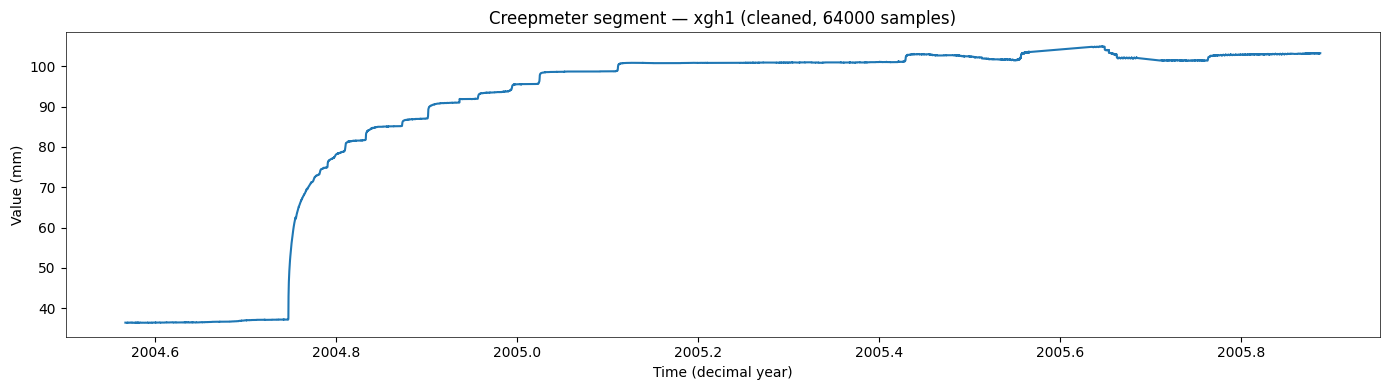

In [72]:
# CELL 22
# Load creepmeter data — configurable station and source
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.
import numpy as np
import os
import gzip
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# CONFIGURE HERE
# ══════════════════════════════════════════════════════════════
# Option A: cleaned data (displacement in mm, gap-filled)
#   station = 'xmr1'
#   source = 'cleaned'
#
# Option B: raw data (counts, may need calibration)
#   station = 'cfwd'
#   source = 'raw'
#
station = 'xgh1'
source = 'cleaned'       # 'cleaned' or 'raw'
raw_era = 'new'      # 'new' or 'old' (only used when source='raw')
seg_len = 64000     # segment length (power of 2 recommended)
start_date = 2004.207    # e.g. 1997.200 = year 1997, day 200. None = auto
end_date = None      # e.g. 2005.365. None = auto
# ══════════════════════════════════════════════════════════════

base_dir = '/Users/amasaryk/projects/Creep'

if source == 'cleaned':
    # Try gz first, then plain
    candidates = [
        f'{base_dir}/Cleaned_data_creep/gz/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        raise FileNotFoundError(f'No cleaned file found for station {station}. '
                                f'Tried: {candidates}')
    opener = gzip.open if fpath.endswith('.gz') else open
    with opener(fpath, 'rt') as f:
        lines = f.readlines()
    unit = 'mm'
    bad_val = -9999

elif source == 'raw':
    # raw/new and raw/old
    candidates = [
        f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/{station}',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        # List available raw files to help the user
        raw_dir = f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/'
        if os.path.isdir(raw_dir):
            avail = sorted(os.listdir(raw_dir))
            print(f'Available raw files: {avail}')
        raise FileNotFoundError(f'No raw file found for station {station}. '
                                f'Tried: {candidates}')
    with open(fpath, 'r') as f:
        lines = f.readlines()
    unit = 'counts'
    bad_val = -9999
else:
    raise ValueError(f"source must be 'cleaned' or 'raw', got '{source}'")

# Parse: year  day_of_year  value
data = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 3:
        try:
            year = float(parts[0])
            doy = float(parts[1])
            val = float(parts[2])
            if val != bad_val:
                t_val = year + doy / 365.25
                data.append((t_val, val))
        except ValueError:
            continue

data = np.array(data)
t_creep = data[:, 0]
x_creep = data[:, 1]
dt_creep = np.median(np.diff(t_creep))

print(f'Loaded {len(x_creep)} samples from {os.path.basename(fpath)} ({source})')
print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
print(f'Value range: {x_creep.min():.3f} to {x_creep.max():.3f} {unit}')

# Apply date range filter if specified
if start_date is not None or end_date is not None:
    # Convert year.doy to decimal year
    def doy_to_decimal(ydoy):
        yr = int(ydoy)
        doy = (ydoy - yr) * 1000  # e.g. 1997.200 -> year=1997, doy=200
        return yr + doy / 365.25
    
    mask = np.ones(len(t_creep), dtype=bool)
    if start_date is not None:
        t_start = doy_to_decimal(start_date)
        mask &= t_creep >= t_start
        print(f'Start filter: {start_date} -> {t_start:.4f} decimal year')
    if end_date is not None:
        t_end = doy_to_decimal(end_date)
        mask &= t_creep <= t_end
        print(f'End filter: {end_date} -> {t_end:.4f} decimal year')
    
    t_creep = t_creep[mask]
    x_creep = x_creep[mask]
    print(f'After date filter: {len(x_creep)} samples')

# Find a clean segment (no gaps)
seg_len = min(seg_len, len(x_creep))
found_clean = False
for start in range(0, len(x_creep) - seg_len, seg_len // 4):
    segment_c = x_creep[start:start + seg_len]
    t_seg_c = t_creep[start:start + seg_len]
    gaps = np.diff(t_seg_c)
    if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
        found_clean = True
        break

if not found_clean:
    # Fall back to first seg_len contiguous samples
    start = 0
    segment_c = x_creep[:seg_len]
    t_seg_c = t_creep[:seg_len]
    print(f'WARNING: no perfectly clean segment found, using first {seg_len} samples')

segment_c = segment_c.copy()
print(f'Using segment of {len(segment_c)} samples starting at index {start}')
print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} {unit}')

fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
ax.plot(t_seg_c, segment_c)
ax.set_xlabel('Time (decimal year)')
ax.set_ylabel(f'Value ({unit})')
ax.set_title(f'Creepmeter segment — {station} ({source}, {len(segment_c)} samples)')
plt.tight_layout()
plt.show()

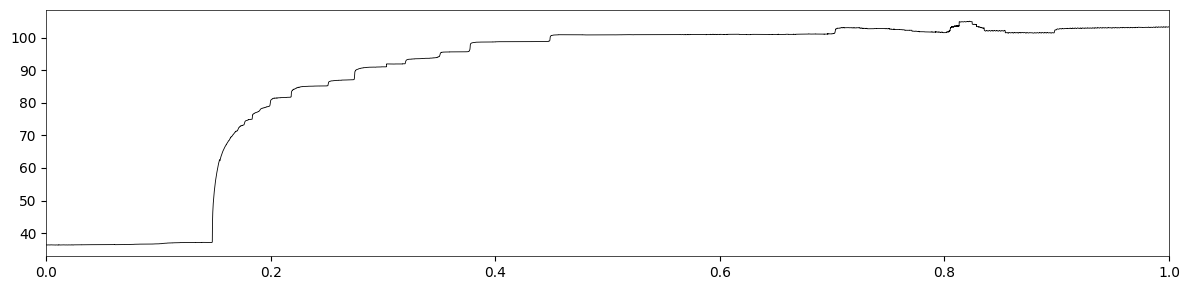

Signal size: 64000
Signal range: [36.3700, 105.0000]
CWT computed in 1.052s  (n_oct=10, n_voice=5, 50 scales)
Coefficients shape: (50, 64000), Scales: 50 (1.00 to 891.44)
Valid range at finest scale: (20, 63979), coarsest: (17971, 46028)


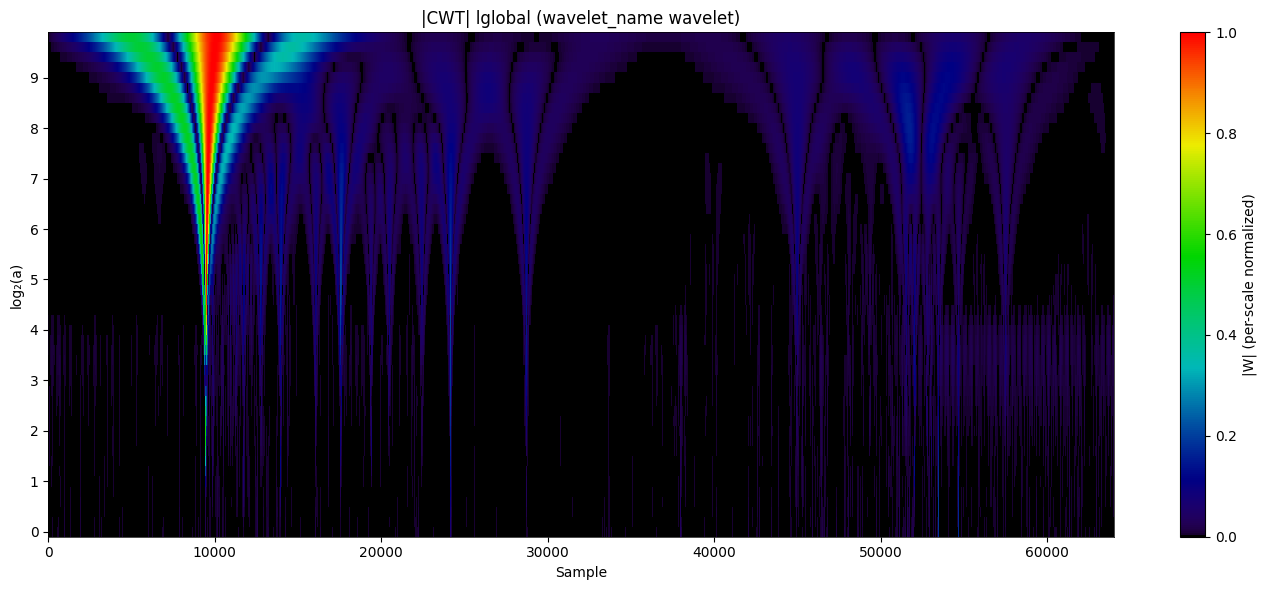

In [73]:
# Cell 13: CWT on selected signal
wavelet_name= "g2"                                                                                                   
                                                                                                                                                                    
analysis_signal = analysis_signal = segment_c                                                                                                          
SIZE = len(segment_c)

SIG_START = 0          # start index                                                                                                                               
SIG_END = SIZE // 2    # end index (e.g., first half)   




# --- CWT parameters (used by all downstream cells) ---
N_OCT = 10
N_VOICE = 5
A_MIN = 1
EXPO = -1.0

fig, ax = plt.subplots(figsize=(12, 3))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) / SIZE
ax.plot(t_axis, analysis_signal, color='black', linewidth=0.6)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}')
print(f'Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')

# CWT + visualization
t0 = time.time()
coeffs, scales, valid_ranges = cwtd_fftw(segment_c, a_min=A_MIN, n_oct=N_OCT, n_voice=N_VOICE,
                                     wavelet_name= 'g3', expo=EXPO)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s  (n_oct={N_OCT}, n_voice={N_VOICE}, {len(scales)} scales)')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode='lglobal')
ax.set_title(f'|CWT| lglobal ({'wavelet_name'} wavelet)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()


Numba warmup: 0.002s
Total extrema: 84762
Extrema computed in 0.030s
  Scale 0 (a=1.00): 11423 extrema
  Scale 12 (a=5.28): 1852 extrema
  Scale 25 (a=32.00): 321 extrema
  Scale 37 (a=168.90): 58 extrema
  Scale 49 (a=891.44): 13 extrema
Chaining: 0.002s
Delete: 0.097s, deleted 40 chains
Pre-chainmax surviving chains: 9986
ChainMax: 0.051s
Total chaining: 0.150s
Remaining extrema: 84718
Pre-deletion chains: 9996
Surviving chains: 9986
Deleted chains: 10


NameError: name 'analysis_label' is not defined

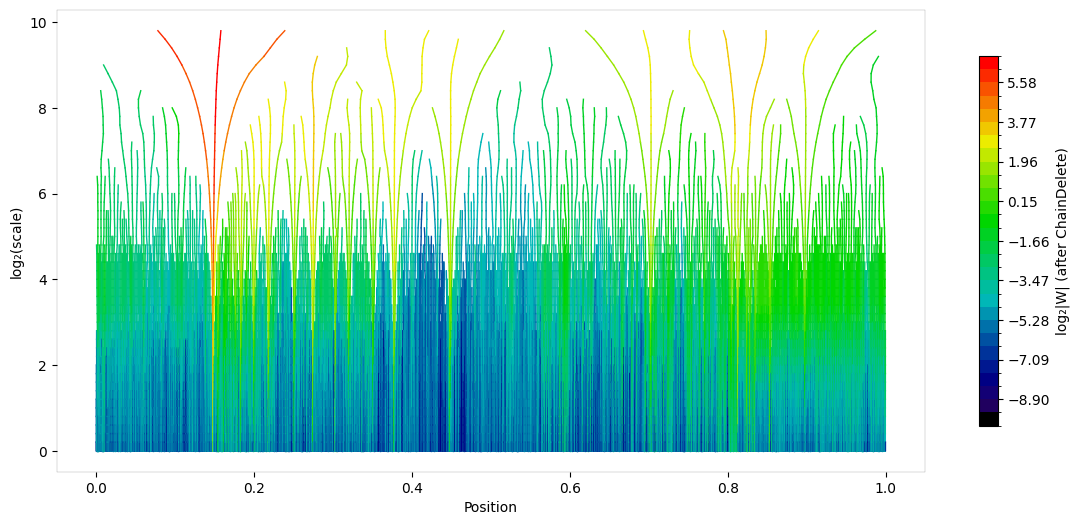

In [74]:
# Cell 15: Extrema detection — now imported from wtmm package
from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
n_total_scales = N_OCT * N_VOICE
for sidx in [0, n_total_scales//4, n_total_scales//2, 3*n_total_scales//4, n_total_scales-1]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

# Cell 16: Chaining — now imported from wtmm package
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=N_OCT, n_voice=N_VOICE)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, N_OCT * N_VOICE)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=N_OCT, n_voice=N_VOICE)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# Trace chains BEFORE chainmax (raw CWT modulus values)
pre_chainmax_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)
print(f'Pre-chainmax surviving chains: {len(pre_chainmax_chains)}')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, expo=0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, vals in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving colored by log2|ordinate|, deleted greyed out
import matplotlib as mpl

N_COLORS = 28
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.1)

# Draw deleted chains first (background, grey)
for pos, sv, sign, vals in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Collect all log2|ordinate| values for colormap normalization
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

# Draw surviving chains colored by log2|ordinate| at each segment
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'{analysis_label} \u2014 {len(post_del_chains)} surviving ({N_COLORS} levels), {len(deleted_chains)} deleted (grey)')
ax.margins(0)
plt.tight_layout()
plt.show()


Chains passing filter: 30 / 9986 (threshold: log2(a) min 4)


NameError: name 'analysis_label' is not defined

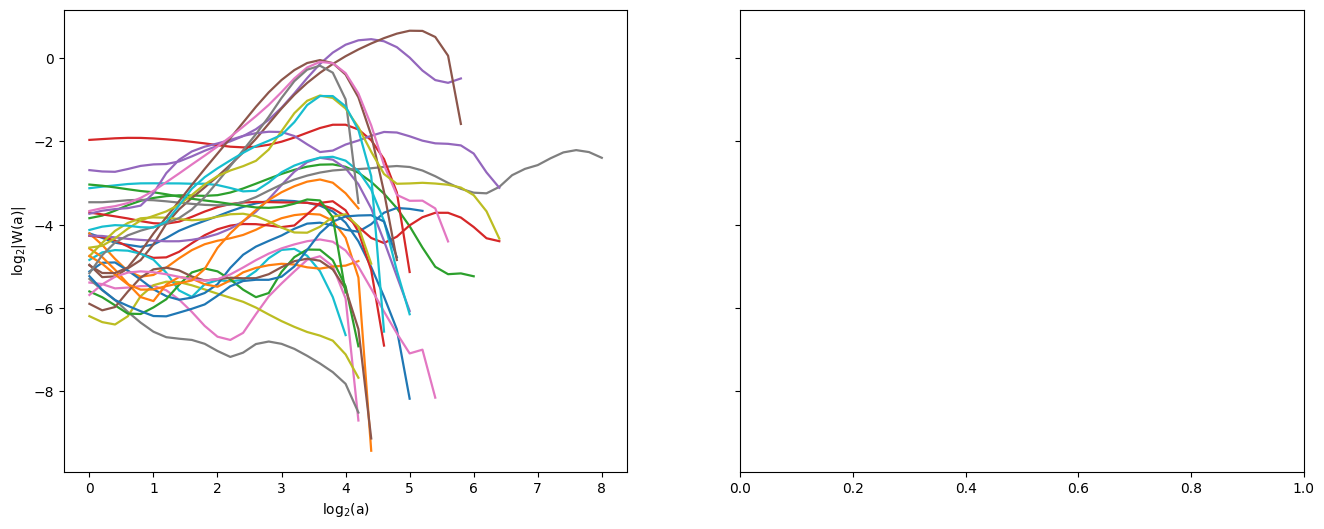

In [75]:
# Hölder exponent visualization: log|W(a)| vs log2(a) for each chain
# Left: raw CWT coefficients along chains
# Right: sup (chainmax) values along chains
# Slope = Hölder exponent h (+ 1/2 for L2 normalization)

SCALE_THRESH = 4       # log2(a) threshold value
SCALE_THRESH_MODE = 'min' # 'min' = chain must reach at least this scale; 'max' = chain must not exceed
MAX_CHAINS_PLOT = 30    # cap to avoid overplotting

# Re-trace chains collecting raw coeffs + chainmax ordinates + scale indices
n_scales_total = N_OCT * N_VOICE
raw_chains = []
sup_chains = []

for fi in range(len(extrep_abs[0])):
    log2_s = []
    raw_vals = []
    sup_vals = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_s.append(np.log2(scales[cs]))
        eidx = extrep_idx[cs][ci]
        raw_vals.append(coeffs[cs, eidx])
        sup_vals.append(extrep_ord[cs][ci])
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_s) > 1:
        log2_s = np.array(log2_s)
        raw_log2 = np.log2(np.abs(np.array(raw_vals)) + 1e-300)
        sup_log2 = np.log2(np.abs(np.array(sup_vals)) + 1e-300)
        raw_chains.append((log2_s, raw_log2))
        sup_chains.append((log2_s, sup_log2))

# Filter by scale threshold
filtered_idx = []
for i, (log2_s, _) in enumerate(raw_chains):
    max_scale = log2_s.max()
    min_scale = log2_s.min()
    if SCALE_THRESH_MODE == 'min':
        if max_scale >= SCALE_THRESH:
            filtered_idx.append(i)
    else:  # 'max'
        if max_scale <= SCALE_THRESH:
            filtered_idx.append(i)

# Subsample if too many
if len(filtered_idx) > MAX_CHAINS_PLOT:
    rng = np.random.default_rng(42)
    filtered_idx = sorted(rng.choice(filtered_idx, MAX_CHAINS_PLOT, replace=False))

print(f'Chains passing filter: {len(filtered_idx)} / {len(raw_chains)} '
      f'(threshold: log2(a) {SCALE_THRESH_MODE} {SCALE_THRESH})')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for panel, (ax, chains, title) in enumerate(zip(
        axes,
        [raw_chains, sup_chains],
        ['Raw CWT coefficients', 'Sup chains (ChainMax)'])):
    for i in filtered_idx:
        log2_s, log2_v = chains[i]
        ax.plot(log2_s, log2_v, '-', alpha=1, linewidth=1.6)
    ax.set_xlabel('log$_2$(a)')
    ax.set_ylabel('log$_2$|W(a)|')
    ax.set_title(f'{title} — {analysis_label}')
    ax.grid(True, alpha=0.3)
    # Reference slopes
    for h in [0.5, 1.0, 1.5]:
        x_ref = np.array([0, N_OCT])
        ax.plot(x_ref, h * x_ref + ax.get_ylim()[0] + 2, '--', color='grey',
                alpha=0.5, linewidth=1, label=f'h={h}' if panel == 0 else None)

axes[0].legend(fontsize=8, loc='lower right')
plt.suptitle(f'Hölder exponent from slope of log|W| vs log(a)', fontsize=13)
plt.tight_layout()
plt.show()

Sup-at-finest filter: removed 5602 chains (20135 extrema)
  Remaining extrema: 57009
  Surviving chains: 4588


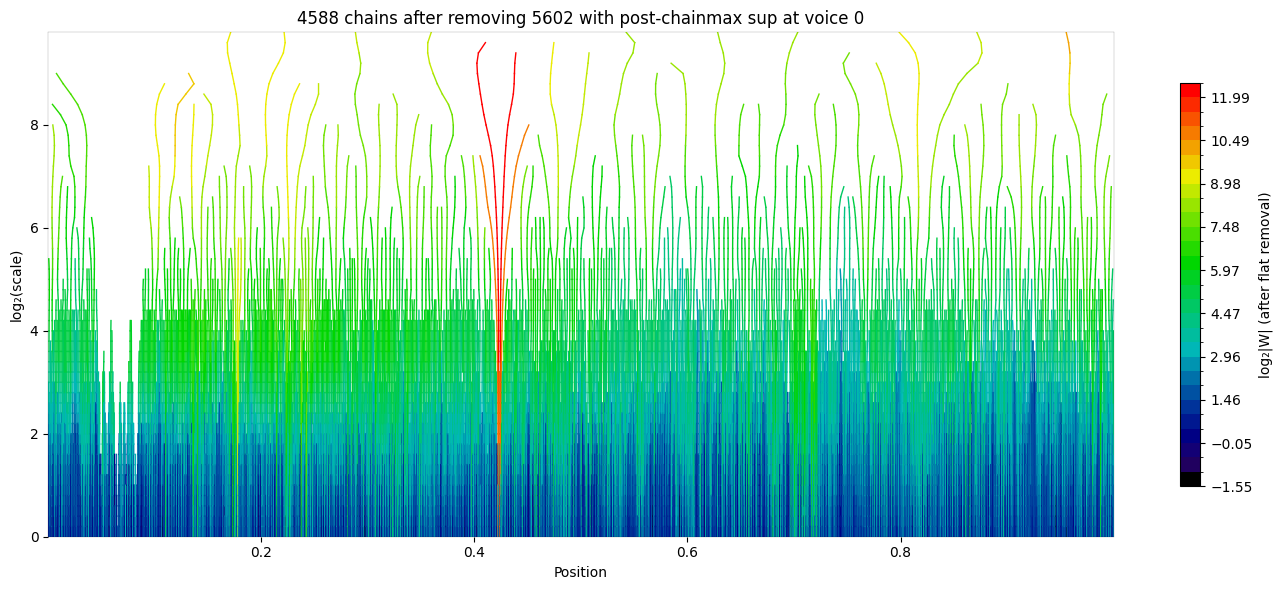

In [58]:
# Remove chains whose post-chainmax sup is at the finest scale
# After chainmax, if the largest |W| is still at voice 0, the chain
# never truly grew with scale — it's h ≤ 0. Physical singularities
# in displacement (h > 0) will have their sup at a coarser scale.

REMOVE_FLAT_CHAINS = True

if REMOVE_FLAT_CHAINS:
    n_scales_total = N_OCT * N_VOICE
    n_finest = len(extrep_abs[0])

    remove_mask = np.zeros(n_finest, dtype=bool)
    for fi in range(n_finest):
        # Walk chain, find scale of post-chainmax sup
        max_cm = -1.0
        max_cs = 0
        cs, ci = 0, fi
        chain_len = 0
        while cs < n_scales_total and ci != -1:
            val = abs(extrep_ord[cs][ci])
            if val > max_cm:
                max_cm = val
                max_cs = cs
            chain_len += 1
            ci = coarser_links[cs][ci]
            cs += 1

        if chain_len < 2 or max_cs == 0:
            remove_mask[fi] = True

    # Collect all extrema to remove
    remove_set = [set() for _ in range(len(extrep_abs))]
    for fi in range(n_finest):
        if not remove_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild arrays
    n_removed_total = 0
    old_to_new = []
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_flagged = int(remove_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'Sup-at-finest filter: removed {n_flagged} chains ({n_removed_total} extrema)')
    print(f'  Remaining extrema: {n_remaining}')

    # Visualize
    post_flat_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales_total)
    print(f'  Surviving chains: {len(post_flat_chains)}')

    import matplotlib as mpl
    N_COLORS = 28
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.1)

    all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                    for _, _, _, vals in post_flat_chains])
    vmin, vmax = np.percentile(all_log2_vals, [0, 100])
    boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
    norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
    cmap = lastwave_colormap(N_COLORS)

    for pos, sv, sign, vals in post_flat_chains:
        log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
        for j in range(len(pos) - 1):
            ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='log₂|W| (after flat removal)', shrink=0.8)
    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{len(post_flat_chains)} chains after removing {n_flagged} with post-chainmax sup at voice 0')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('Flat-chain filtering: disabled (REMOVE_FLAT_CHAINS = False)')

Sup at coarser scale (surviving): 9986 chains
Sup at voice 0 (removed, from pre-chainmax): 6523 chains


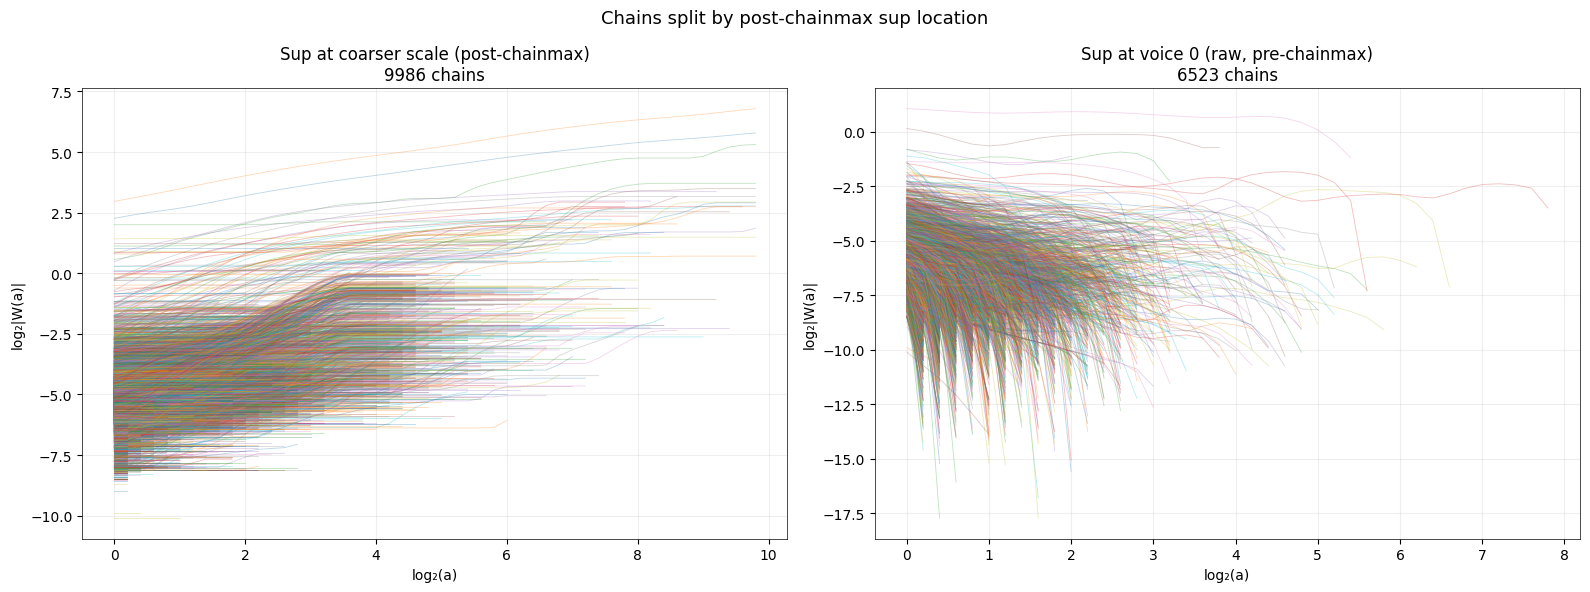

In [76]:
# Split chains by post-chainmax sup location
# Uses pre_chainmax_chains (saved before flat-chain removal in cell 10)
# Left: chains whose sup is NOT at voice 0 — plot post-chainmax values
# Right: chains whose sup IS at voice 0 — plot raw (pre-chainmax) values

import matplotlib.pyplot as plt
import numpy as np

n_scales_total = N_OCT * N_VOICE

sup_coarse = []  # (log2_a, log2w) — sup at coarser scale
sup_finest = []  # sup at voice 0

for fi in range(len(extrep_abs[0])):
    # Walk surviving chains (post cell 10) for the "good" group
    log2_a_list = []
    cm_list = []
    max_cm = -1.0
    max_cs = 0
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_a_list.append(np.log2(scales[cs]))
        val = abs(extrep_ord[cs][ci])
        cm_list.append(np.log2(val + 1e-300))
        if val > max_cm:
            max_cm = val
            max_cs = cs
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_a_list) >= 2:
        sup_coarse.append((np.array(log2_a_list), np.array(cm_list)))

# For the removed chains, use pre_chainmax_chains (saved in cell 7, before any removal)
# These have raw CWT values; check sup location on those
for pos, sv, sign, vals in pre_chainmax_chains:
    if len(sv) < 2:
        continue
    abs_vals = np.abs(np.array(vals))
    max_idx = np.argmax(abs_vals)
    if max_idx == 0:  # sup at finest scale
        log2_a = np.array(sv)
        log2_w = np.log2(abs_vals + 1e-300)
        sup_finest.append((log2_a, log2_w))

print(f'Sup at coarser scale (surviving): {len(sup_coarse)} chains')
print(f'Sup at voice 0 (removed, from pre-chainmax): {len(sup_finest)} chains')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Left: sup NOT at voice 0 — post-chainmax
ax = axes[0]
for log2_a, log2_w in sup_coarse:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at coarser scale (post-chainmax)\n{len(sup_coarse)} chains')
ax.grid(True, alpha=0.2)

# Right: sup at voice 0 — raw pre-chainmax
ax = axes[1]
for log2_a, log2_w in sup_finest:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at voice 0 (raw, pre-chainmax)\n{len(sup_finest)} chains')
ax.grid(True, alpha=0.2)

plt.suptitle('Chains split by post-chainmax sup location', fontsize=13)
plt.tight_layout()
plt.show()

Sup coarser (h>0 group): 185 chains, h median=0.427, R² median=0.788
Sup finest  (h≤0 group): 116 chains, h median=-2.427, R² median=0.889


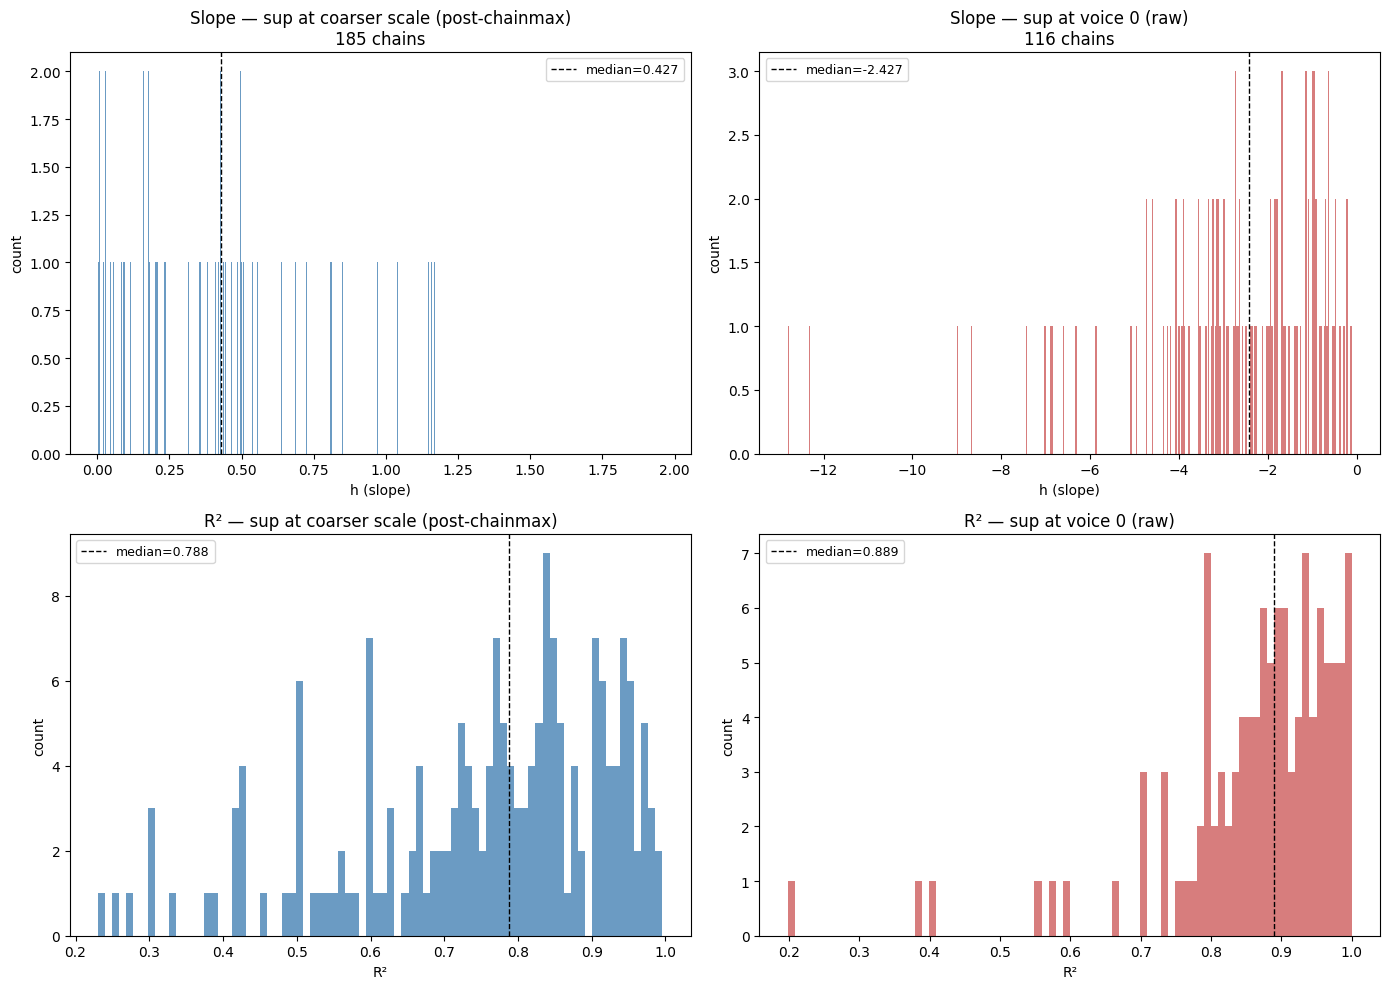

In [41]:
# Histograms of Hölder exponent (slope) and R² for both chain groups
import matplotlib.pyplot as plt
import numpy as np

# Compute slopes and R² for sup-at-coarser chains (post-chainmax)
h_pos = []
r2_pos = []
for log2_a, log2_w in sup_coarse:
    if len(log2_a) < 3:
        continue
    coeffs_fit = np.polyfit(log2_a, log2_w, 1)
    slope = coeffs_fit[0]
    pred = np.polyval(coeffs_fit, log2_a)
    ss_res = np.sum((log2_w - pred)**2)
    ss_tot = np.sum((log2_w - np.mean(log2_w))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
    h_pos.append(slope)
    r2_pos.append(r2)

# Compute slopes and R² for sup-at-finest chains (raw, pre-chainmax)
h_neg = []
r2_neg = []
for log2_a, log2_w in sup_finest:
    if len(log2_a) < 3:
        continue
    coeffs_fit = np.polyfit(log2_a, log2_w, 1)
    slope = coeffs_fit[0]
    pred = np.polyval(coeffs_fit, log2_a)
    ss_res = np.sum((log2_w - pred)**2)
    ss_tot = np.sum((log2_w - np.mean(log2_w))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
    h_neg.append(slope)
    r2_neg.append(r2)

h_pos = np.array(h_pos)
r2_pos = np.array(r2_pos)
h_neg = np.array(h_neg)
r2_neg = np.array(r2_neg)

print(f'Sup coarser (h>0 group): {len(h_pos)} chains, h median={np.median(h_pos):.3f}, R² median={np.median(r2_pos):.3f}')
print(f'Sup finest  (h≤0 group): {len(h_neg)} chains, h median={np.median(h_neg):.3f}, R² median={np.median(r2_neg):.3f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: slope histogram — h>0 group (post-chainmax)
ax = axes[0, 0]
ax.hist(h_pos, bins=2000, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(np.median(h_pos), color='k', ls='--', lw=1, label=f'median={np.median(h_pos):.3f}')
ax.set_xlabel('h (slope)')
ax.set_ylabel('count')
ax.set_title(f'Slope — sup at coarser scale (post-chainmax)\n{len(h_pos)} chains')
ax.legend(fontsize=9)

# Top right: slope histogram — h≤0 group (raw)
ax = axes[0, 1]
ax.hist(h_neg, bins=400, color='indianred', alpha=0.8, edgecolor='none')
ax.axvline(np.median(h_neg), color='k', ls='--', lw=1, label=f'median={np.median(h_neg):.3f}')
ax.set_xlabel('h (slope)')
ax.set_ylabel('count')
ax.set_title(f'Slope — sup at voice 0 (raw)\n{len(h_neg)} chains')
ax.legend(fontsize=9)

# Bottom left: R² histogram — h>0 group
ax = axes[1, 0]
ax.hist(r2_pos, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(np.median(r2_pos), color='k', ls='--', lw=1, label=f'median={np.median(r2_pos):.3f}')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title(f'R² — sup at coarser scale (post-chainmax)')
ax.legend(fontsize=9)

# Bottom right: R² histogram — h≤0 group
ax = axes[1, 1]
ax.hist(r2_neg, bins=80, color='indianred', alpha=0.8, edgecolor='none')
ax.axvline(np.median(r2_neg), color='k', ls='--', lw=1, label=f'median={np.median(r2_neg):.3f}')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title(f'R² — sup at voice 0 (raw)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

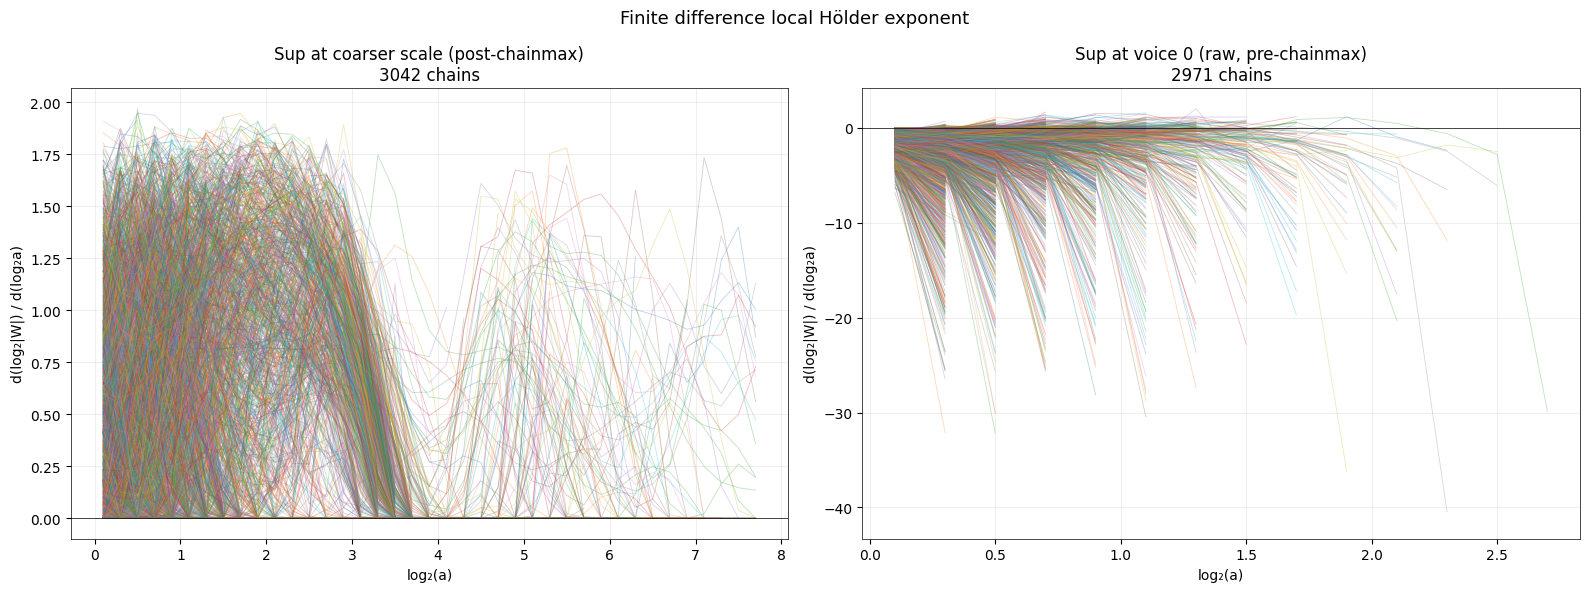

In [ ]:
# Finite difference derivatives d(log₂|W|)/d(log₂a) for both groups
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Left: sup at coarser scale (post-chainmax)
ax = axes[0]
for log2_a, log2_w in sup_coarse:
    if len(log2_a) < 2:
        continue
    d_log2w = np.diff(log2_w)
    d_log2a = np.diff(log2_a)
    deriv = d_log2w / d_log2a
    mid_a = 0.5 * (log2_a[:-1] + log2_a[1:])
    ax.plot(mid_a, deriv, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('d(log₂|W|) / d(log₂a)')
ax.set_title(f'Sup at coarser scale (post-chainmax)\n{len(sup_coarse)} chains')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='k', lw=0.5)

# Right: sup at voice 0 (raw, pre-chainmax)
ax = axes[1]
for log2_a, log2_w in sup_finest:
    if len(log2_a) < 2:
        continue
    d_log2w = np.diff(log2_w)
    d_log2a = np.diff(log2_a)
    deriv = d_log2w / d_log2a
    mid_a = 0.5 * (log2_a[:-1] + log2_a[1:])
    ax.plot(mid_a, deriv, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('d(log₂|W|) / d(log₂a)')
ax.set_title(f'Sup at voice 0 (raw, pre-chainmax)\n{len(sup_finest)} chains')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='k', lw=0.5)

plt.suptitle('Finite difference local Hölder exponent', fontsize=13)
plt.tight_layout()
plt.show()

R² ≥ 0.997:
  Sup coarser: 80 / 3042 chains
  Sup finest:  97 / 2971 chains


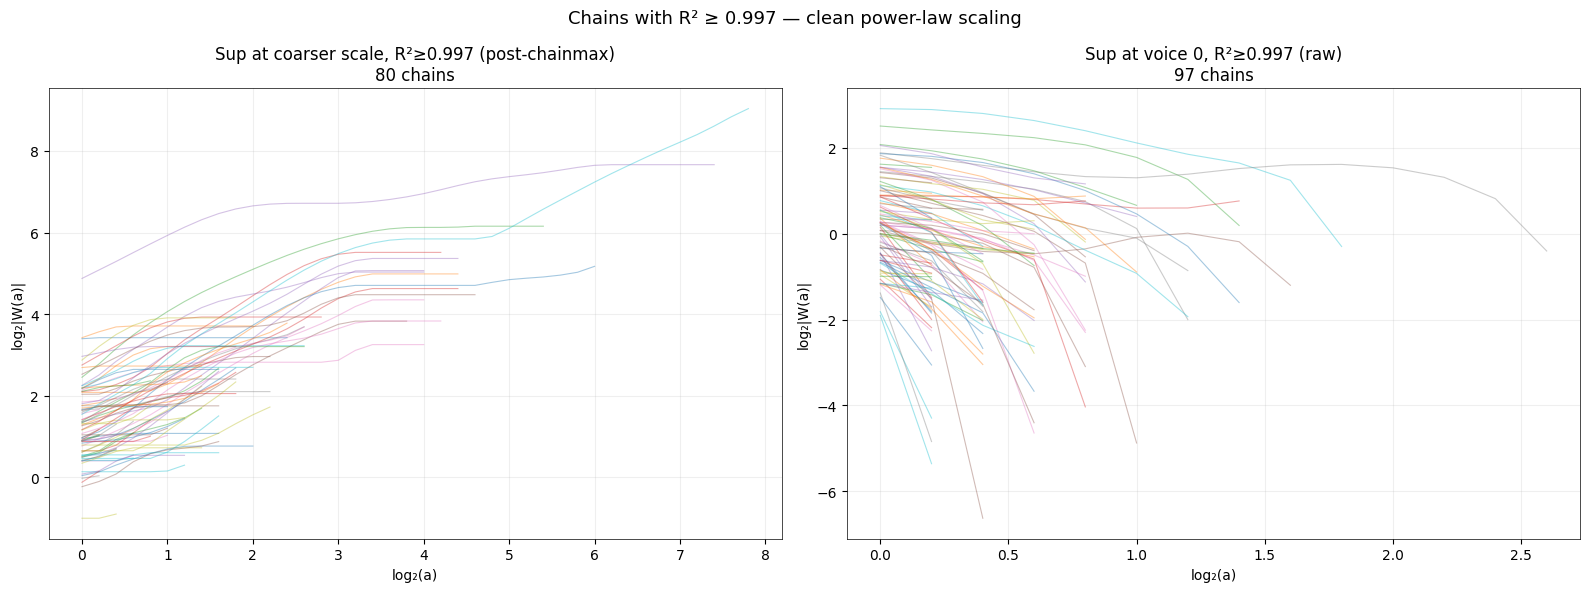

In [ ]:
# Chains with R² > 0.95 from both groups
# High R² = clean power-law scaling, likely real singularities
# Low R² = noisy / non-power-law, likely artifacts or masked
import matplotlib.pyplot as plt
import numpy as np

R2_THRESH = 0.997

# Filter sup-at-coarser group (post-chainmax)
good_pos = [(la, lw) for (la, lw), r2 in zip(sup_coarse, r2_pos) if r2 >= R2_THRESH]
# Filter sup-at-finest group (raw)
good_neg = [(la, lw) for (la, lw), r2 in zip(sup_finest, r2_neg) if r2 >= R2_THRESH]

print(f'R² ≥ {R2_THRESH}:')
print(f'  Sup coarser: {len(good_pos)} / {len(sup_coarse)} chains')
print(f'  Sup finest:  {len(good_neg)} / {len(sup_finest)} chains')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
for log2_a, log2_w in good_pos:
    ax.plot(log2_a, log2_w, '-', alpha=0.4, lw=0.8)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at coarser scale, R²≥{R2_THRESH} (post-chainmax)\n{len(good_pos)} chains')
ax.grid(True, alpha=0.2)

ax = axes[1]
for log2_a, log2_w in good_neg:
    ax.plot(log2_a, log2_w, '-', alpha=0.4, lw=0.8)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at voice 0, R²≥{R2_THRESH} (raw)\n{len(good_neg)} chains')
ax.grid(True, alpha=0.2)

plt.suptitle(f'Chains with R² ≥ {R2_THRESH} — clean power-law scaling', fontsize=13)
plt.tight_layout()
plt.show()

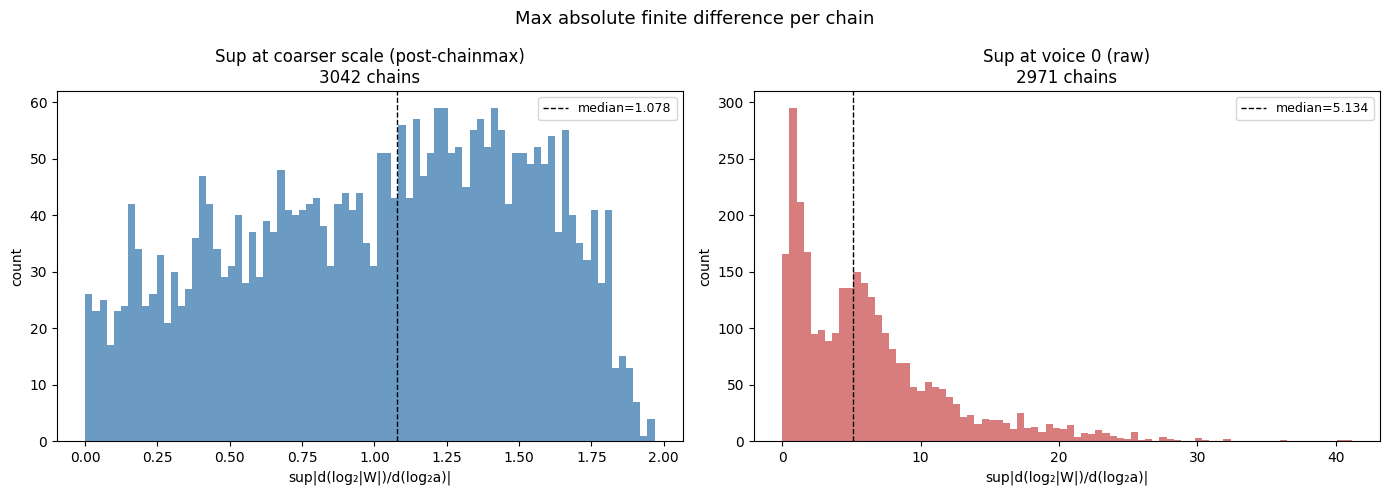

In [ ]:
# Histograms of sup|finite difference| for each group
# sup of |d(log₂|W|)/d(log₂a)| per chain — measures the maximum
# local rate of change along the chain
import matplotlib.pyplot as plt
import numpy as np

sup_fd_pos = []
for log2_a, log2_w in sup_coarse:
    if len(log2_a) < 2:
        continue
    deriv = np.diff(log2_w) / np.diff(log2_a)
    sup_fd_pos.append(np.max(np.abs(deriv)))

sup_fd_neg = []
for log2_a, log2_w in sup_finest:
    if len(log2_a) < 2:
        continue
    deriv = np.diff(log2_w) / np.diff(log2_a)
    sup_fd_neg.append(np.max(np.abs(deriv)))

sup_fd_pos = np.array(sup_fd_pos)
sup_fd_neg = np.array(sup_fd_neg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(sup_fd_pos, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(np.median(sup_fd_pos), color='k', ls='--', lw=1, label=f'median={np.median(sup_fd_pos):.3f}')
ax.set_xlabel('sup|d(log₂|W|)/d(log₂a)|')
ax.set_ylabel('count')
ax.set_title(f'Sup at coarser scale (post-chainmax)\n{len(sup_fd_pos)} chains')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(sup_fd_neg, bins=80, color='indianred', alpha=0.8, edgecolor='none')
ax.axvline(np.median(sup_fd_neg), color='k', ls='--', lw=1, label=f'median={np.median(sup_fd_neg):.3f}')
ax.set_xlabel('sup|d(log₂|W|)/d(log₂a)|')
ax.set_ylabel('count')
ax.set_title(f'Sup at voice 0 (raw)\n{len(sup_fd_neg)} chains')
ax.legend(fontsize=9)

plt.suptitle('Max absolute finite difference per chain', fontsize=13)
plt.tight_layout()
plt.show()

Chains with |h_chainmax| < 0.002: 20
Removed 20 h≈0 chains (167 extrema)
Remaining extrema: 35362


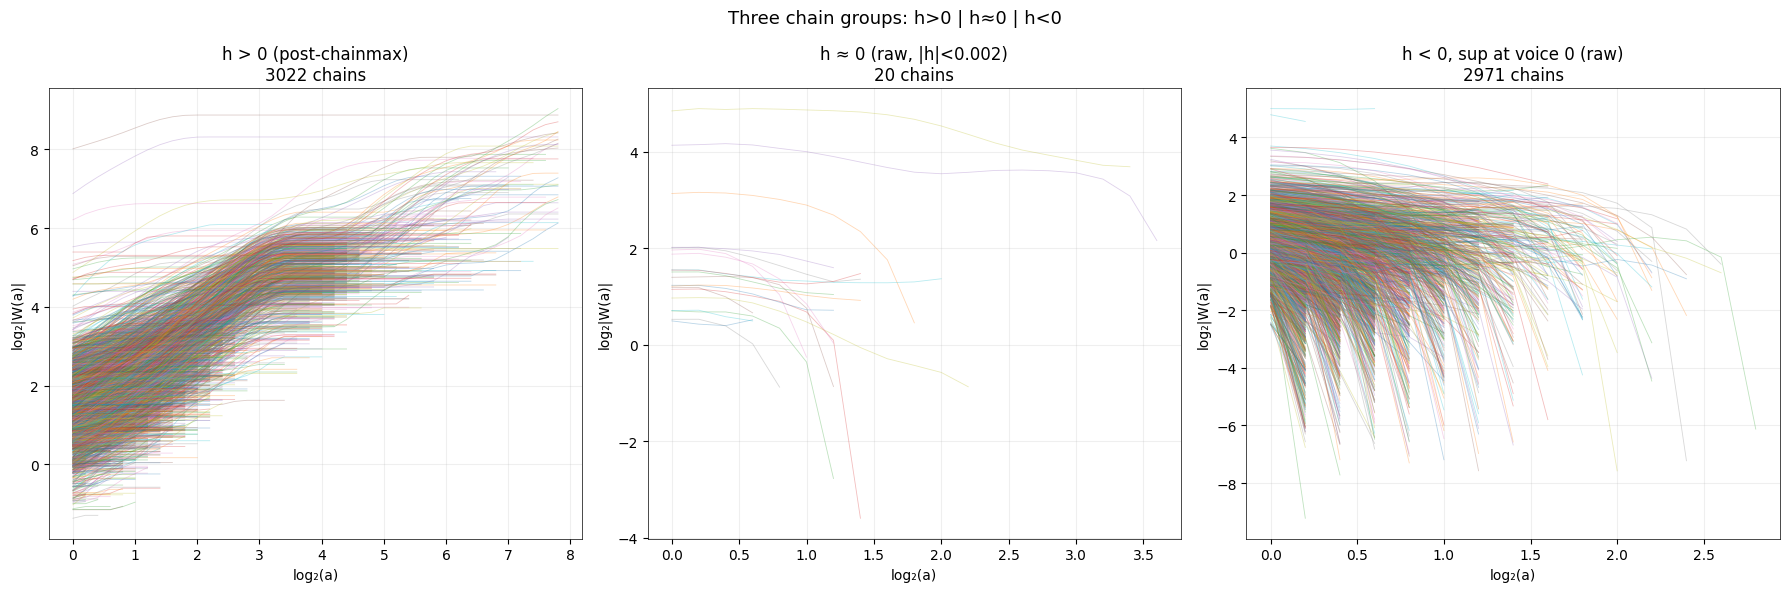

In [ ]:
# Remove chains from the surviving (sup-at-coarser) group whose
# post-chainmax slope is h ≈ 0 (within H_ZERO_TOL).
# These slipped through chainmax with a tiny positive slope but
# are effectively flat — not real singularities.

H_ZERO_TOL = 0.002

n_scales_total = N_OCT * N_VOICE
n_finest = len(extrep_abs[0])

# Identify chains with |h| < H_ZERO_TOL from post-chainmax slope
remove_mask = np.zeros(n_finest, dtype=bool)
h_zero_chains_raw = []  # save raw log-log for plotting

for fi in range(n_finest):
    log2_a_list = []
    cm_list = []
    raw_list = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_a_list.append(np.log2(scales[cs]))
        eidx = extrep_idx[cs][ci]
        raw_list.append(np.log2(abs(coeffs[cs, eidx]) + 1e-300))
        cm_list.append(np.log2(abs(extrep_ord[cs][ci]) + 1e-300))
        ci = coarser_links[cs][ci]
        cs += 1

    if len(log2_a_list) < 3:
        continue

    log2_a = np.array(log2_a_list)
    cm_log2w = np.array(cm_list)
    h_cm = np.polyfit(log2_a, cm_log2w, 1)[0]

    if abs(h_cm) < H_ZERO_TOL:
        remove_mask[fi] = True
        h_zero_chains_raw.append((log2_a, np.array(raw_list)))

n_h_zero = int(remove_mask.sum())
print(f'Chains with |h_chainmax| < {H_ZERO_TOL}: {n_h_zero}')

# Remove from extrep
remove_set = [set() for _ in range(len(extrep_abs))]
for fi in range(n_finest):
    if not remove_mask[fi]:
        continue
    cs, ci = 0, fi
    while cs < len(extrep_abs) and ci != -1:
        remove_set[cs].add(ci)
        ci = coarser_links[cs][ci]
        cs += 1

n_removed_total = 0
old_to_new = []
for s in range(len(extrep_abs)):
    n_old = len(extrep_abs[s])
    to_remove = remove_set[s]
    n_removed_total += len(to_remove)

    if len(to_remove) == 0:
        old_to_new.append({i: i for i in range(n_old)})
        continue

    keep_mask = np.array([i not in to_remove for i in range(n_old)])
    mapping = {}
    new_idx = 0
    for old_idx in range(n_old):
        if keep_mask[old_idx]:
            mapping[old_idx] = new_idx
            new_idx += 1
        else:
            mapping[old_idx] = -1
    old_to_new.append(mapping)

    extrep_abs[s] = extrep_abs[s][keep_mask]
    extrep_ord[s] = extrep_ord[s][keep_mask]
    extrep_idx[s] = extrep_idx[s][keep_mask]

for s in range(len(coarser_links)):
    n_cur = len(extrep_abs[s])
    new_cl = np.full(n_cur, -1, dtype=int)
    new_fl = np.full(n_cur, -1, dtype=int)

    old_cl = coarser_links[s]
    old_fl = finer_links[s]
    mapping_cur = old_to_new[s]
    mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
    mapping_finer = old_to_new[s - 1] if s > 0 else {}

    for old_idx, new_idx in mapping_cur.items():
        if new_idx == -1:
            continue
        if old_idx < len(old_cl):
            old_target = old_cl[old_idx]
            if old_target != -1 and old_target in mapping_coarser:
                new_cl[new_idx] = mapping_coarser[old_target]
            else:
                new_cl[new_idx] = -1
        if old_idx < len(old_fl):
            old_target = old_fl[old_idx]
            if old_target != -1 and old_target in mapping_finer:
                new_fl[new_idx] = mapping_finer[old_target]
            else:
                new_fl[new_idx] = -1

    coarser_links[s] = new_cl
    finer_links[s] = new_fl

n_remaining = sum(len(a) for a in extrep_abs)
print(f'Removed {n_h_zero} h≈0 chains ({n_removed_total} extrema)')
print(f'Remaining extrema: {n_remaining}')

# Plot the three groups
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Re-walk surviving chains for the h>0 group
surviving = []
for fi in range(len(extrep_abs[0])):
    log2_a_list = []
    cm_list = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_a_list.append(np.log2(scales[cs]))
        cm_list.append(np.log2(abs(extrep_ord[cs][ci]) + 1e-300))
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_a_list) >= 2:
        surviving.append((np.array(log2_a_list), np.array(cm_list)))

ax = axes[0]
for log2_a, log2_w in surviving:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'h > 0 (post-chainmax)\n{len(surviving)} chains')
ax.grid(True, alpha=0.2)

ax = axes[1]
for log2_a, raw_log2w in h_zero_chains_raw:
    ax.plot(log2_a, raw_log2w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'h ≈ 0 (raw, |h|<{H_ZERO_TOL})\n{len(h_zero_chains_raw)} chains')
ax.grid(True, alpha=0.2)

ax = axes[2]
for log2_a, log2_w in sup_finest:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'h < 0, sup at voice 0 (raw)\n{len(sup_finest)} chains')
ax.grid(True, alpha=0.2)

plt.suptitle('Three chain groups: h>0 | h≈0 | h<0', fontsize=13)
plt.tight_layout()
plt.show()

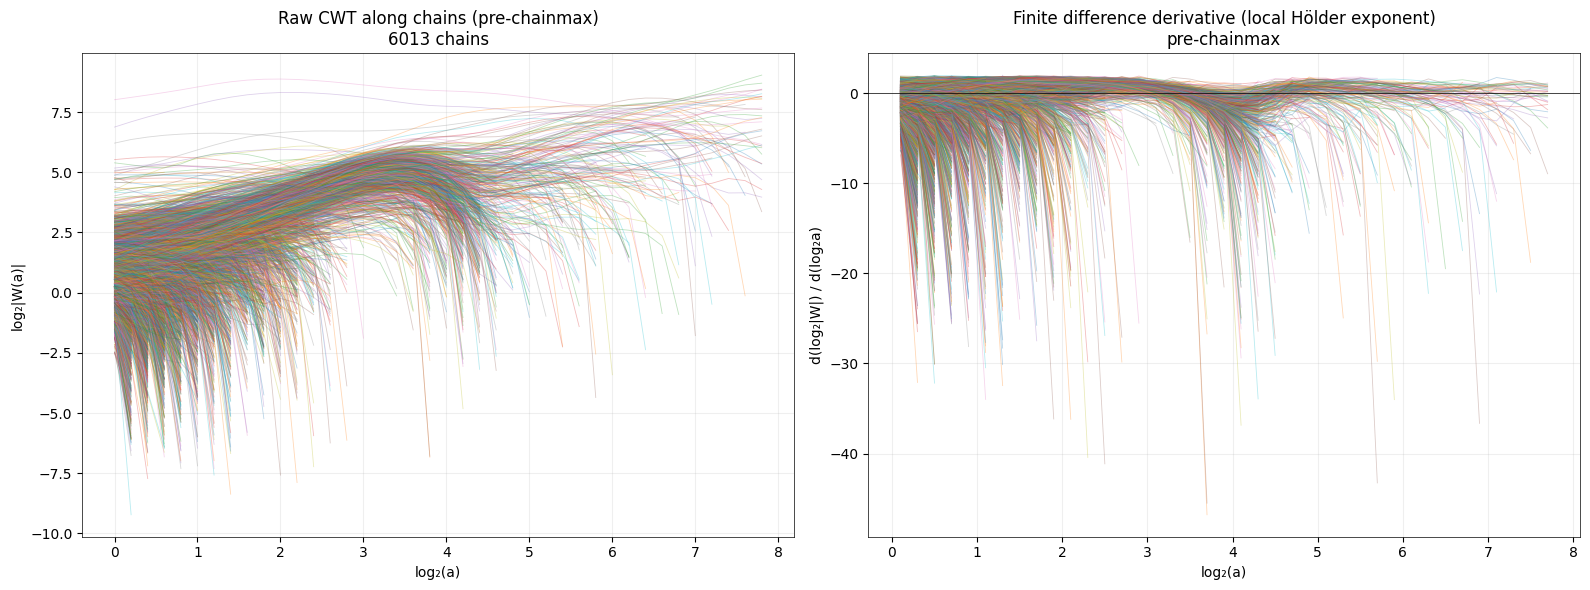

Chains: 6013, length range: [2, 40]
Mean chain length: 7.9 scales


In [ ]:
# Hölder exponent visualization: log|W(a)| vs log₂(a) for each chain
# Plot finite difference derivative d(log₂|W|)/d(log₂a) for each chain
# BEFORE chainmax — raw CWT modulus values along skeleton lines
# The derivative at each scale gives the local Hölder exponent estimate

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Left panel: log₂|W(a)| vs log₂(a) for each chain (raw, pre-chainmax)
ax = axes[0]
for pos, sv, sign, vals in pre_chainmax_chains:
    log2_w = np.log2(np.abs(np.array(vals)) + 1e-300)
    ax.plot(sv, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Raw CWT along chains (pre-chainmax)\n{len(pre_chainmax_chains)} chains')
ax.grid(True, alpha=0.2)

# Right panel: finite difference derivative d(log₂|W|)/d(log₂a)
ax = axes[1]
for pos, sv, sign, vals in pre_chainmax_chains:
    log2_w = np.log2(np.abs(np.array(vals)) + 1e-300)
    log2_a = np.array(sv)
    if len(log2_a) < 2:
        continue
    # Finite difference: Δ(log₂|W|) / Δ(log₂a)
    d_log2w = np.diff(log2_w)
    d_log2a = np.diff(log2_a)
    deriv = d_log2w / d_log2a
    # Plot at midpoints
    mid_a = 0.5 * (log2_a[:-1] + log2_a[1:])
    ax.plot(mid_a, deriv, '-', alpha=0.3, lw=0.6)

ax.set_xlabel('log₂(a)')
ax.set_ylabel('d(log₂|W|) / d(log₂a)')
ax.set_title('Finite difference derivative (local Hölder exponent)\npre-chainmax')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='k', lw=0.5, ls='-')

plt.tight_layout()
plt.show()

# Summary statistics
n_chains = len(pre_chainmax_chains)
chain_lengths = [len(sv) for _, sv, _, _ in pre_chainmax_chains]
print(f'Chains: {n_chains}, length range: [{min(chain_lengths)}, {max(chain_lengths)}]')
print(f'Mean chain length: {np.mean(chain_lengths):.1f} scales')

COI filtering: removed 6448 chains (46995 extrema across all scales)
  COI boundary (coarsest scale): position [0.2808, 0.7192]
  COI boundary (indices): [17971, 46028] of 64000
  Remaining extrema: 37723
  Surviving chains after COI filter: 4335


NameError: name 'analysis_label' is not defined

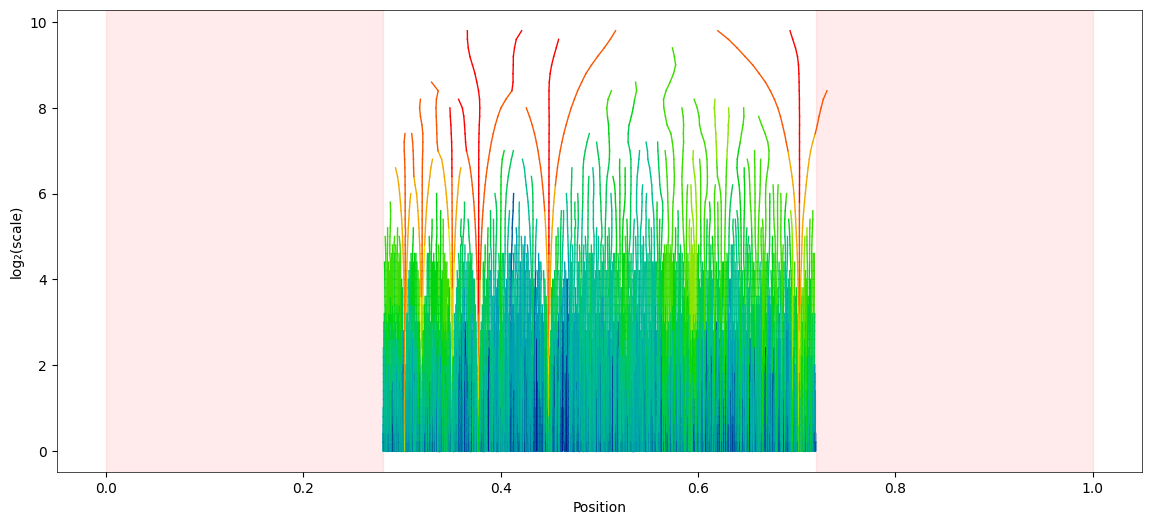

In [77]:
# Cell 17b: Cone-of-influence chain filtering
# Remove chains whose finest-scale position falls within the COI
# of the coarsest scale (boundary region where edge effects dominate).

REMOVE_COI_CHAINS = True  # <-- toggle this

if REMOVE_COI_CHAINS:
    # COI boundary from the coarsest scale's valid range
    coarsest_scale_idx = len(scales) - 1
    coi_left_idx, coi_right_idx = valid_ranges[coarsest_scale_idx]
    coi_left_pos = coi_left_idx * dx_signal   # convert index to position
    coi_right_pos = coi_right_idx * dx_signal

    # Find which finest-scale extrema are in the COI
    # (position < coi_left_pos or position > coi_right_pos)
    n_finest = len(extrep_abs[0])
    coi_mask = np.zeros(n_finest, dtype=bool)  # True = in COI, remove
    for fi in range(n_finest):
        pos = extrep_abs[0][fi]
        if pos < coi_left_pos or pos > coi_right_pos:
            coi_mask[fi] = True

    # Walk each COI chain from finest to coarsest, collecting (scale, index) to remove
    remove_set = []  # list of sets, one per scale
    for s in range(len(extrep_abs)):
        remove_set.append(set())

    for fi in range(n_finest):
        if not coi_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild extrep arrays, removing marked extrema
    # Build index mapping (old -> new) per scale for link fixup
    n_removed_total = 0
    old_to_new = []  # per scale
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up coarser_links and finer_links with new indices
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            # Coarser link
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            # Finer link
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_coi_chains = int(coi_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'COI filtering: removed {n_coi_chains} chains ({n_removed_total} extrema across all scales)')
    print(f'  COI boundary (coarsest scale): position [{coi_left_pos:.4f}, {coi_right_pos:.4f}]')
    print(f'  COI boundary (indices): [{coi_left_idx}, {coi_right_idx}] of {SIZE}')
    print(f'  Remaining extrema: {n_remaining}')

    # Re-trace surviving chains for visualization
    post_coi_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)
    print(f'  Surviving chains after COI filter: {len(post_coi_chains)}')

    # Visualization: show COI boundaries on maxima lines
    import matplotlib as mpl
    N_COLORS = 14
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    # COI shading
    ax.axvspan(0, coi_left_pos, color='red', alpha=0.08, label='COI (removed)')
    ax.axvspan(coi_right_pos, 1.0, color='red', alpha=0.08)

    # Surviving chains colored by log2|ordinate|
    if len(post_coi_chains) > 0:
        all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                        for _, _, _, vals in post_coi_chains])
        vmin, vmax = np.percentile(all_log2_vals, [0, 100])
        boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
        norm_c = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
        cmap_c = lastwave_colormap(N_COLORS)
        for pos, sv, sign, vals in post_coi_chains:
            log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
            for j in range(len(pos) - 1):
                ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap_c(norm_c(log2_v[j])), lw=1)

    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{analysis_label} — {len(post_coi_chains)} chains after COI filter '
                 f'({n_coi_chains} removed)')
    ax.legend(fontsize=8, loc='upper right')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('COI filtering: disabled (REMOVE_COI_CHAINS = False)')


NameError: name 'analysis_label' is not defined

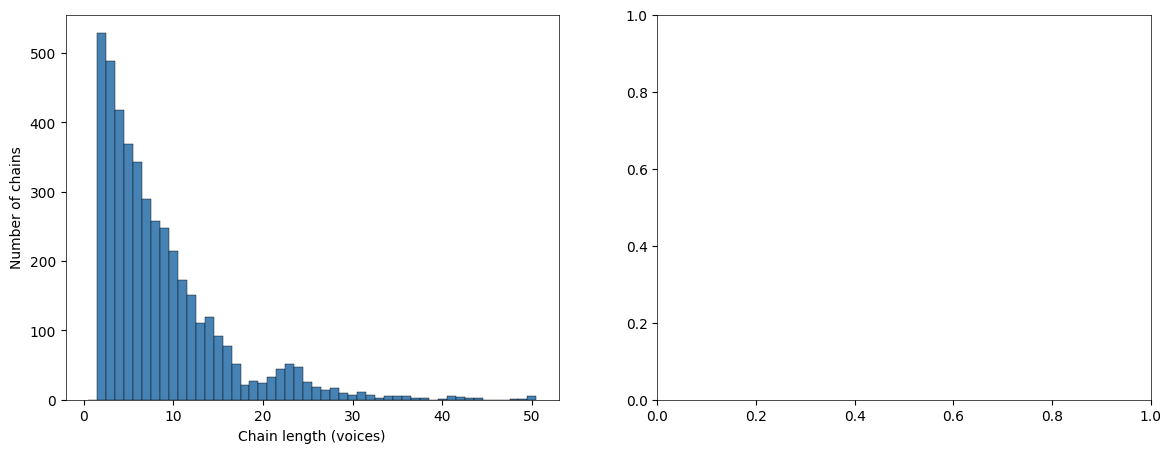

In [78]:
# Cell 17c: Chain length statistics
# Histogram of chain lengths + survival CDF

chains_to_use = post_coi_chains if REMOVE_COI_CHAINS else trace_chains(
    extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)

# Chain length = number of scales spanned (= number of points in chain)
chain_lengths = np.array([len(pos) for pos, _, _, _ in chains_to_use])
max_len = N_OCT * N_VOICE  # maximum possible length

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax in (ax1, ax2):
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# --- Left: Histogram ---
bins = np.arange(0.5, max_len + 1.5, 1)
ax1.hist(chain_lengths, bins=bins, color='steelblue', edgecolor='k', linewidth=0.3)
ax1.set_xlabel('Chain length (voices)')
ax1.set_ylabel('Number of chains')
ax1.set_title(f'{analysis_label} — Chain length distribution (N={len(chain_lengths)})')
ax1.axvline(np.median(chain_lengths), color='red', ls='--', lw=1, label=f'median={np.median(chain_lengths):.0f}')
ax1.axvline(np.mean(chain_lengths), color='orange', ls='--', lw=1, label=f'mean={np.mean(chain_lengths):.1f}')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)

# --- Right: Survival CDF  N(L > l) vs l ---
voice_vals = np.arange(1, max_len + 1)
survival = np.array([np.sum(chain_lengths > v) for v in voice_vals])
ax2.semilogy(voice_vals, survival, 'ko-', markersize=3, linewidth=1)
ax2.set_xlabel('Chain length threshold (voices)')
ax2.set_ylabel('Number of chains > threshold')
ax2.set_title(f'{analysis_label} — Chain survival CDF')
ax2.set_xlim(0, max_len + 1)
ax2.grid(True, alpha=0.2, which='both')

# Mark reference lengths at each octave
for ref in [N_VOICE, 2*N_VOICE, 3*N_VOICE]:
    if ref <= max_len:
        n_above = int(np.sum(chain_lengths > ref))
        ax2.axvline(ref, color='gray', ls=':', lw=0.8)
        ax2.annotate(f'{ref}v: {n_above}', (ref, max(n_above, 1)),
                     fontsize=7, ha='left', va='bottom')

plt.tight_layout()
plt.show()

print(f'Total chains: {len(chain_lengths)}')
print(f'Length range: [{chain_lengths.min()}, {chain_lengths.max()}] voices')
print(f'Mean: {chain_lengths.mean():.1f}, Median: {np.median(chain_lengths):.0f}')

In [ ]:
# Cell 17d: Filter extrema by minimum chain length
# Only keep extrema belonging to chains >= MIN_CHAIN_LENGTH voices.
# Short chains are unreliable (noise, edge artifacts).

FILTER_BY_CHAIN_LENGTH = True   # <-- toggle
MIN_CHAIN_LENGTH = 3 * N_VOICE  # e.g. chains spanning at least 3 octaves

if FILTER_BY_CHAIN_LENGTH:
    # Identify which extrema at each scale belong to long-enough chains.
    # Strategy: walk each chain from finest scale, mark all its extrema
    # as keep/remove based on chain length.

    # Build chain membership: for each scale, which extrema are in long chains?
    keep_sets = [set() for _ in range(len(extrep_abs))]

    # Trace chains from finest scale
    n_finest = len(extrep_abs[0])
    n_kept_chains = 0
    n_removed_chains = 0

    for fi in range(n_finest):
        # Walk this chain to measure its length
        chain_indices = []  # list of (scale_idx, extremum_idx)
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            chain_indices.append((cs, ci))
            ci = coarser_links[cs][ci]
            cs += 1

        if len(chain_indices) >= MIN_CHAIN_LENGTH:
            n_kept_chains += 1
            for s, idx in chain_indices:
                keep_sets[s].add(idx)
        else:
            n_removed_chains += 1

    # Rebuild extrep arrays keeping only marked extrema
    n_removed_total = 0
    old_to_new = []
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_keep = keep_sets[s]
        n_remove = n_old - len(to_keep)
        n_removed_total += n_remove

        if n_remove == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i in to_keep for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up links
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'Chain length filter (>= {MIN_CHAIN_LENGTH} voices):')
    print(f'  Kept {n_kept_chains} chains, removed {n_removed_chains}')
    print(f'  Removed {n_removed_total} extrema, {n_remaining} remaining')
else:
    print('Chain length filtering: disabled (FILTER_BY_CHAIN_LENGTH = False)')

Partition function computed in 0.012s, up to scale index 49
Extrema per scale (sample): [4975 4335 3806 3318 2900]...[7 7 7 6 5]


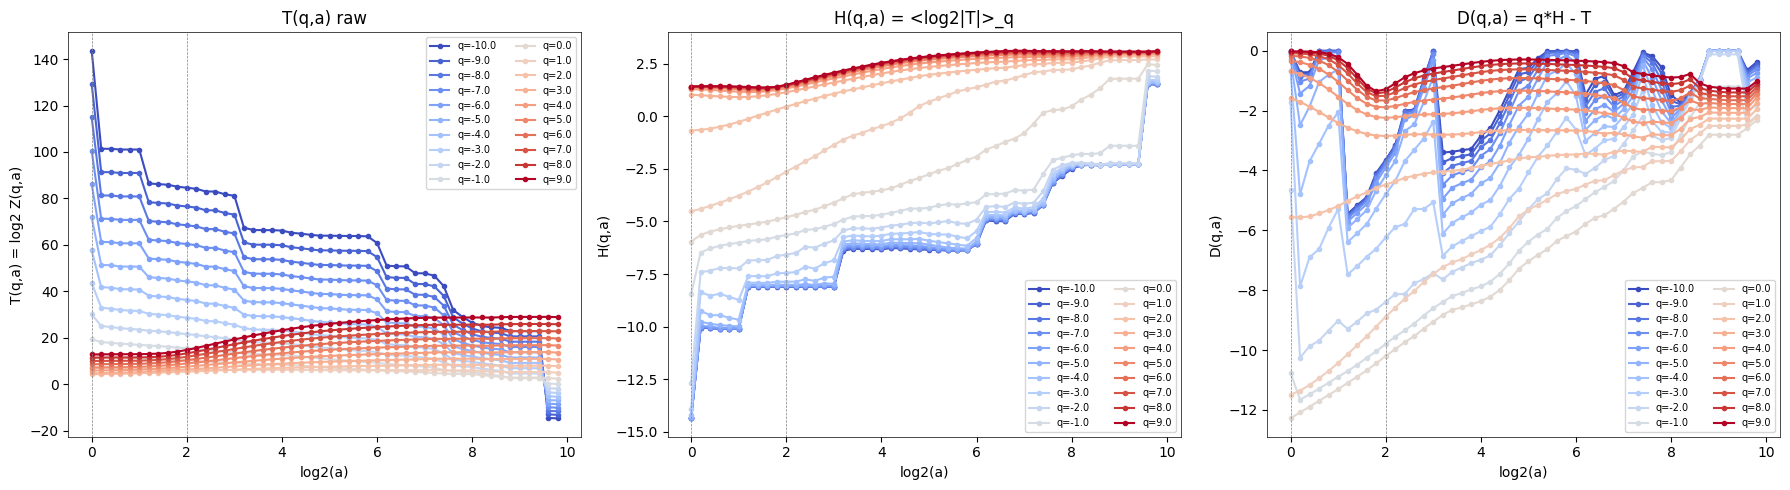

Gray dashed lines show regression range [log2(a)=0.0 to 2]


In [98]:
# Cell 18: Partition function — now imported from wtmm package
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
LOG2_A_MIN = 0.0
LOG2_A_MAX = 2

# Compute partition function
#q_list = [-100, -50, -10, -5, -4, -3, -2, -1, -.5, -.25, 0, .1, .2, .3, .4, .5, 1, 2]#np.arange(-3, 3, .1)]  #[ -.5, -.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75,  2, 3]
q_list = np.arange(-10, 10, 1)
t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Normalize partition function plots by detrending T(q,a) by tau(1)*log2(a)
NORMALIZE_PF_PLOT = False
tau_1_pf = 0.0
if NORMALIZE_PF_PLOT:
    q1_i = np.argmin(np.abs(pf['q_list'] - 1.0))
    _x = pf['log2_a'][:pf['index_max'] + 1]
    _y = pf_get_T(pf, q1_i)[:pf['index_max'] + 1]
    _fin = np.isfinite(_y)
    if _fin.sum() >= 2:
        tau_1_pf = np.polyfit(_x[_fin], _y[_fin], 1)[0]
        print(f'tau(1) = {tau_1_pf:.4f} (used to detrend T and D plots)')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid] - tau_1_pf * log2_a[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) - τ(1)·log₂(a)' if NORMALIZE_PF_PLOT else 'T(q,a) = log2 Z(q,a)')
ax.set_title('T(q,a) normalized' if NORMALIZE_PF_PLOT else 'T(q,a) raw')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid] + tau_1_pf * log2_a[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a) + τ(1)·log₂(a)' if NORMALIZE_PF_PLOT else 'D(q,a)')
ax.set_title('D(q,a) normalized' if NORMALIZE_PF_PLOT else 'D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print(f'Gray dashed lines show regression range [log2(a)={LOG2_A_MIN} to {LOG2_A_MAX}]')


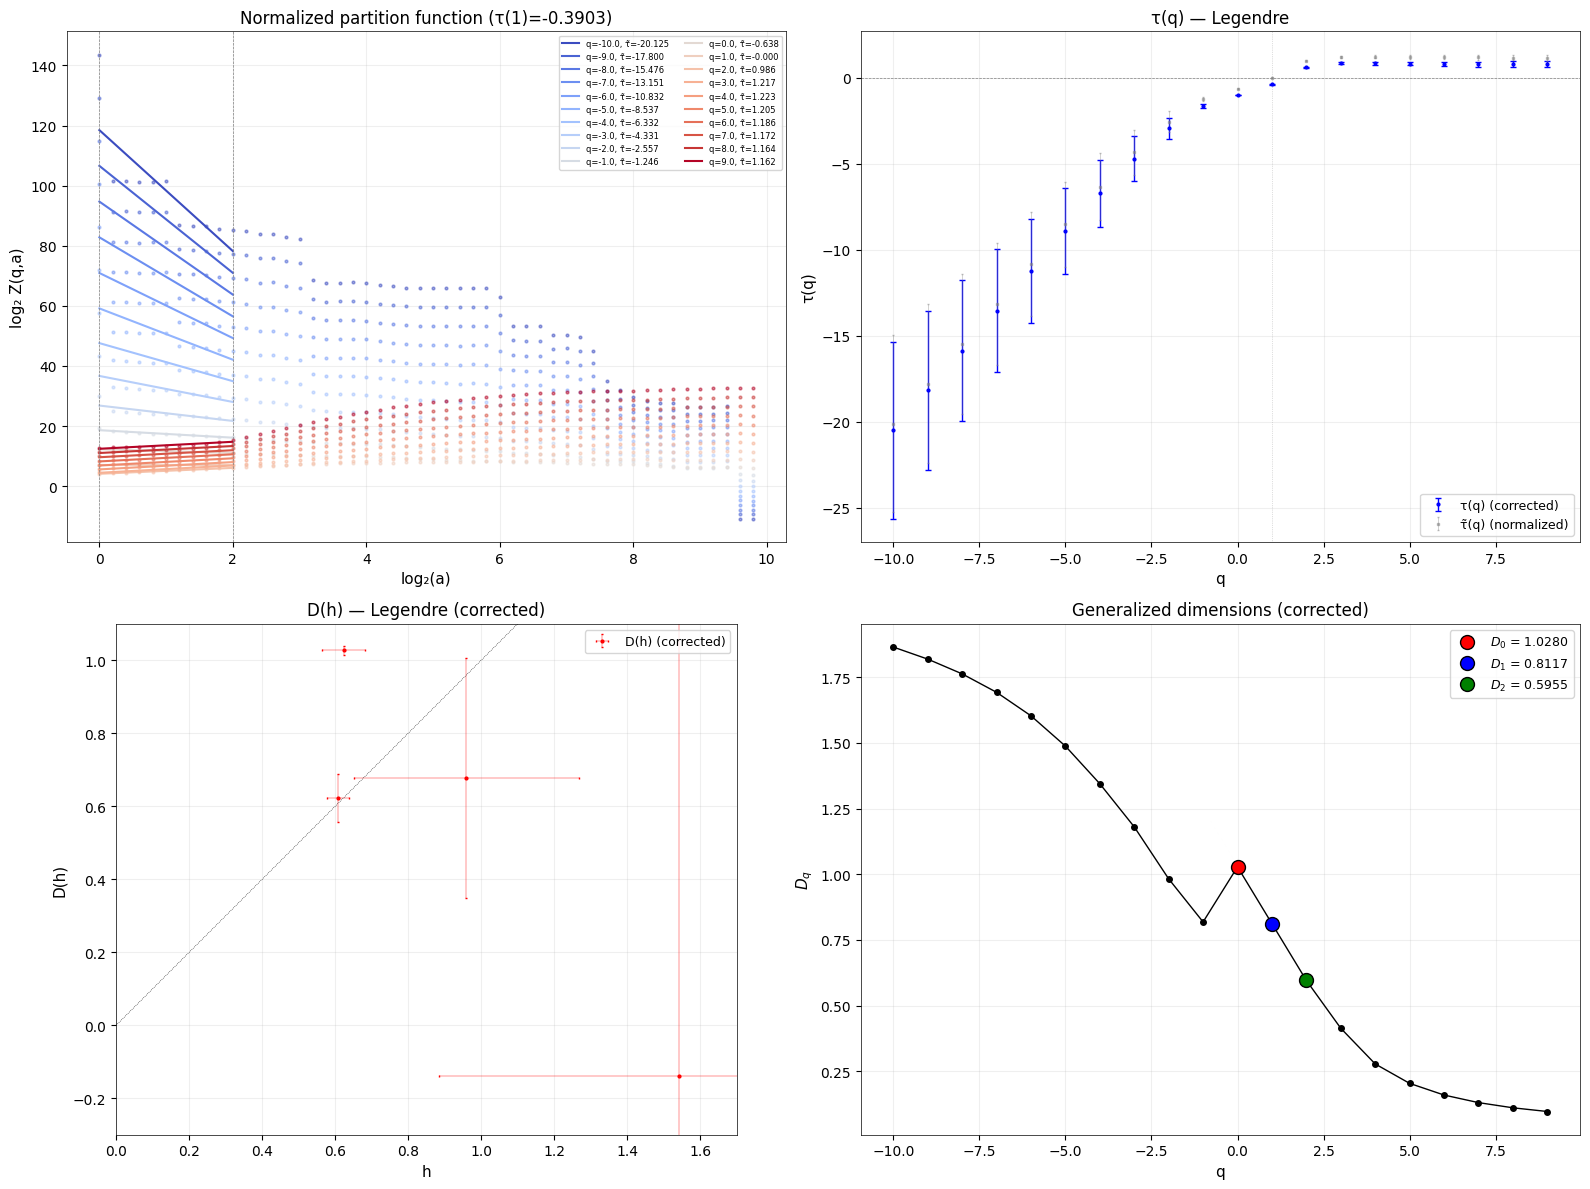

τ(1) = -0.3903
τ̃(1) = -0.000000 (should be ≈0)
τ(0) = -1.0280 → D_f = -τ(0) = 1.0280
h range: [0.1186, 1.5424]
D(h) peak: 1.2021 at h = 0.8117

Generalized dimensions (corrected):
  D_0 = 1.0280  (box-counting)
  D_1 = 0.8117  (information)
  D_2 = 0.5955  (correlation)


In [99]:
# Normalized partition function Z̃(q,a) = Z(q,a)/a^{τ(1)} with regression + error bars
# τ(q) from slopes of log₂ Z̃ vs log₂(a), then D(h) via Legendre transform
#
# NOTE: τ̃(q) = τ(q) - τ(1). After fitting, correct back:
#   τ_true = τ̃ + τ(1),  D_true = D̃ - τ(1),  h unchanged.

from wtmm.partition import pf_get_T

# --- Regression range ---
log2_a_full = pf['log2_a']
dx = 1.0 / pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
idx_min = max(int((LOG2_A_MIN - log2_a0) / dx), 0)
idx_max = min(int((LOG2_A_MAX - log2_a0) / dx), pf['index_max'])
fit_idx = np.arange(idx_min, idx_max + 1)
x_fit = log2_a0 + dx * fit_idx

q_arr = pf['q_list']
n_q = len(q_arr)

# --- First pass: get tau(1) for normalization ---
q1_i = np.argmin(np.abs(q_arr - 1.0))
y_T1 = pf_get_T(pf, q1_i)[fit_idx]
tau_1_val = np.polyfit(x_fit[np.isfinite(y_T1)], y_T1[np.isfinite(y_T1)], 1)[0]

# --- Fit τ̃(q) from normalized T̃(q,a) with standard errors ---
tau_q_norm = np.full(n_q, np.nan)
tau_err = np.full(n_q, np.nan)
intercepts = np.full(n_q, np.nan)

for i in range(n_q):
    y_T = pf_get_T(pf, i)[fit_idx] - tau_1_val * (log2_a0 + dx * fit_idx)
    fin = np.isfinite(y_T)
    if fin.sum() >= 3:
        coeffs, cov = np.polyfit(x_fit[fin], y_T[fin], 1, cov=True)
        tau_q_norm[i] = coeffs[0]
        tau_err[i] = np.sqrt(cov[0, 0])
        intercepts[i] = coeffs[1]

# --- Correct back to true values ---
tau_q = tau_q_norm + tau_1_val

# --- Legendre transform: h(q) = dτ/dq, D(h) = q*h - τ ---
# h is the same whether computed from τ̃ or τ (constant drops out of derivative)
h_q = np.gradient(tau_q_norm, q_arr)

# D from normalized, then correct: D̃ = q*h - τ̃, D_true = D̃ - τ(1)
D_q_norm = q_arr * h_q - tau_q_norm
D_q = D_q_norm - tau_1_val

# Error propagation for h(q) = dτ/dq via central differences
# σ_h² ≈ (σ_τ[i+1]² + σ_τ[i-1]²) / (2*dq)²  (interior points)
h_err = np.full(n_q, np.nan)
for i in range(1, n_q - 1):
    dq_i = q_arr[i+1] - q_arr[i-1]
    h_err[i] = np.sqrt(tau_err[i+1]**2 + tau_err[i-1]**2) / abs(dq_i)
# Endpoints: forward/backward difference
if n_q > 1:
    h_err[0] = tau_err[1] / abs(q_arr[1] - q_arr[0]) if np.isfinite(tau_err[1]) else np.nan
    h_err[-1] = tau_err[-2] / abs(q_arr[-1] - q_arr[-2]) if np.isfinite(tau_err[-2]) else np.nan

# D error: σ_D² = q²σ_h² + σ_τ²  (h and τ correlated but this is approximate)
D_err = np.sqrt(q_arr**2 * h_err**2 + tau_err**2)

# --- Generalized dimensions D_q = τ(q)/(q-1), corrected ---
D_q_renyi = np.full(n_q, np.nan)
for i in range(n_q):
    if np.isclose(q_arr[i], 1.0):
        D_q_renyi[i] = h_q[i]  # L'Hôpital: lim τ/(q-1) = dτ/dq at q=1
    elif np.isfinite(tau_q[i]):
        D_q_renyi[i] = tau_q[i] / (q_arr[i] - 1.0)

# ================ PLOTS ================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax_ in axes.flat:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# --- Panel 1: Normalized partition function with regression lines ---
ax = axes[0, 0]
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, n_q))
x_full = log2_a_full[valid]

for i in range(n_q):
    y = pf_get_T(pf, i)[valid] - tau_1_val * x_full
    ax.plot(x_full, y, 'o', color=colors[i], markersize=2, alpha=0.5)
    # Regression line in fit range
    if np.isfinite(tau_q_norm[i]):
        y_line = tau_q_norm[i] * x_fit + intercepts[i]
        ax.plot(x_fit, y_line, '-', color=colors[i], linewidth=1.5,
                label=f'q={q_arr[i]:.1f}, τ̃={tau_q_norm[i]:.3f}')

ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)', fontsize=11)
ax.set_ylabel('log₂ Z̃(q,a)', fontsize=11)
ax.set_title(f'Normalized partition function (τ(1)={tau_1_val:.4f})', fontsize=12)
ax.legend(fontsize=6, ncol=2, loc='best')
ax.grid(True, alpha=0.2)

# --- Panel 2: τ(q) with error bars (TRUE, corrected) ---
ax = axes[0, 1]
fin = np.isfinite(tau_q)
ax.errorbar(q_arr[fin], tau_q[fin], yerr=tau_err[fin],
            fmt='bo', markersize=2, capsize=2, linewidth=1, label='τ(q) (corrected)')
ax.errorbar(q_arr[fin], tau_q_norm[fin], yerr=tau_err[fin],
            fmt='s', color='gray', markersize=2, capsize=1, linewidth=0.5,
            alpha=0.5, label='τ̃(q) (normalized)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.axvline(1, color='gray', ls=':', lw=0.5, alpha=0.5)
ax.set_xlabel('q', fontsize=11)
ax.set_ylabel('τ(q)', fontsize=11)
ax.set_title('τ(q) — Legendre', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# --- Panel 3: D(h) singularity spectrum (TRUE, corrected) ---
ax = axes[1, 0]
fin = np.isfinite(h_q) & np.isfinite(D_q) & (D_q > -0.5)
ax.errorbar(h_q[fin], D_q[fin], xerr=h_err[fin], yerr=D_err[fin],
            fmt='ro', markersize=2, capsize=1, linewidth=.3, alpha=1, label='D(h) (corrected)')
h_ref = np.linspace(0, max(h_q[fin].max(), 1), 100)
ax.plot(h_ref, h_ref, 'k:', linewidth=0.5, alpha=1)
ax.set_xlabel('h', fontsize=11)
ax.set_ylabel('D(h)', fontsize=11)
ax.set_xlim(0, 1.7)
ax.set_ylim(-0.3, 1.1)
ax.set_aspect('equal')
ax.set_title('D(h) — Legendre (corrected)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# --- Panel 4: Generalized dimensions D_q (TRUE, corrected) ---
ax = axes[1, 1]
fin_r = np.isfinite(D_q_renyi)
ax.plot(q_arr[fin_r], D_q_renyi[fin_r], 'ko-', markersize=4, linewidth=1)
for q_val, name, color in [(0, '$D_0$', 'red'),
                            (1, '$D_1$', 'blue'),
                            (2, '$D_2$', 'green')]:
    idx = np.where(np.isclose(q_arr, q_val))[0]
    if len(idx) > 0 and np.isfinite(D_q_renyi[idx[0]]):
        ax.plot(q_val, D_q_renyi[idx[0]], 'o', color=color, markersize=10,
                markeredgecolor='k', zorder=5,
                label=f'{name} = {D_q_renyi[idx[0]]:.4f}')
ax.set_xlabel('q', fontsize=11)
ax.set_ylabel('$D_q$', fontsize=11)
ax.set_title('Generalized dimensions (corrected)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print(f'τ(1) = {tau_1_val:.4f}')
print(f'τ̃(1) = {tau_q_norm[q1_i]:.6f} (should be ≈0)')
print(f'τ(0) = {tau_q[np.argmin(np.abs(q_arr))]:.4f} → D_f = -τ(0) = {-tau_q[np.argmin(np.abs(q_arr))]:.4f}')
print(f'h range: [{h_q[fin].min():.4f}, {h_q[fin].max():.4f}]')
print(f'D(h) peak: {D_q[fin].max():.4f} at h = {h_q[fin][np.argmax(D_q[fin])]:.4f}')
q0_i = np.argmin(np.abs(q_arr))
q2_i = np.argmin(np.abs(q_arr - 2.0))
print(f'\nGeneralized dimensions (corrected):')
print(f'  D_0 = {D_q_renyi[q0_i]:.4f}  (box-counting)')
print(f'  D_1 = {D_q_renyi[q1_i]:.4f}  (information)')
print(f'  D_2 = {D_q_renyi[q2_i]:.4f}  (correlation)')

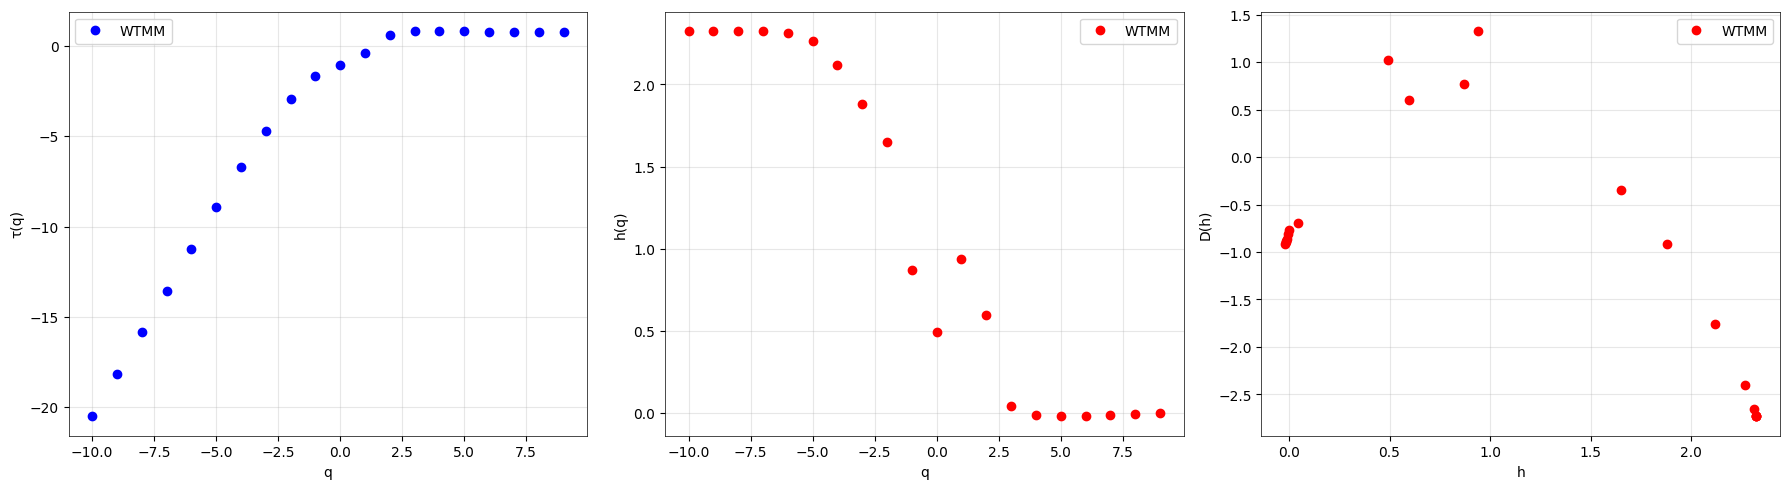

In [100]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra

# Compute spectra
spectra = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)


# 1. tau(q)
ax = axes[0]

ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('\u03c4(q)')

ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q)
ax = axes[1]

ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')

ax.legend()
ax.grid(True, alpha=0.3)


# 3. D(h) singularity spectrum
ax = axes[2]

ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, linestyle='none', label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


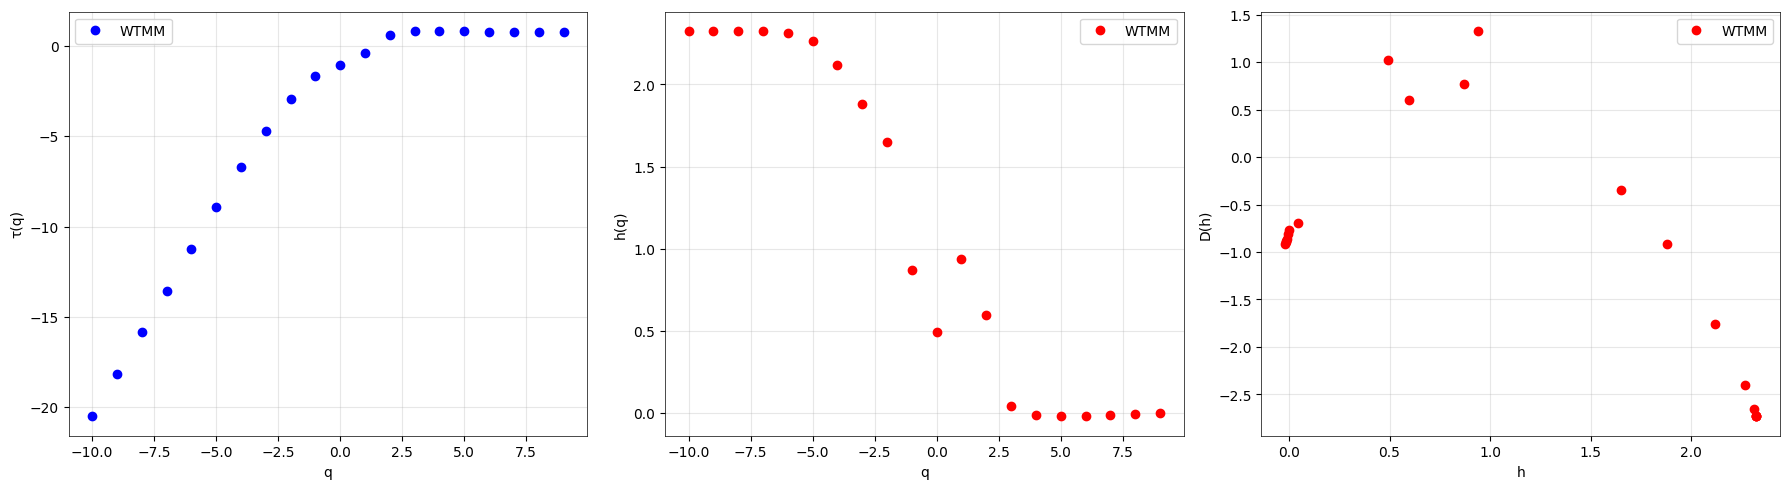

In [101]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra

# Compute spectra
spectra = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)


# 1. tau(q)
ax = axes[0]

ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('\u03c4(q)')

ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q)
ax = axes[1]

ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')

ax.legend()
ax.grid(True, alpha=0.3)


# 3. D(h) singularity spectrum
ax = axes[2]

ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, linestyle='none', label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Selected q = 1.000
  h(q) = 0.9294
  D(h)  = 1.0343
  τ(q)  = -0.1049
  Tangent: y = 1.000·h - (-0.1049)
  y-intercept (h=0): 0.1049


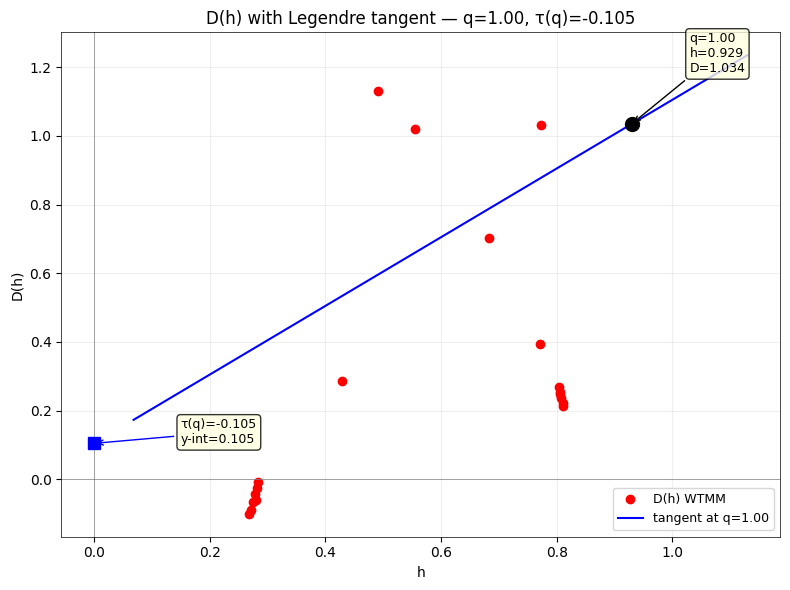

In [87]:
# Legendre tangent visualization on D(h) spectrum
# Select a q value; the tangent line to D(h) at the corresponding
# point has slope q and y-intercept τ(q):
#   D(h) ≈ q·h - τ(q)  ⟹  tangent line: y = q·(h - h*) + D(h*)
#   y-intercept at h=0: q·h* - D(h*) = τ(q) ... but we draw the
#   line y = q*h - τ(q) directly (the Legendre transform).

Q_SELECT = 1  # <-- change this

# Find closest q in the computed spectra
q_arr = spectra['q_list']
qi = np.argmin(np.abs(q_arr - Q_SELECT))
q_val = q_arr[qi]
h_val = spectra['h_q'][qi]
D_val = spectra['D_q'][qi]
tau_val = spectra['tau_q'][qi]

print(f'Selected q = {q_val:.3f}')
print(f'  h(q) = {h_val:.4f}')
print(f'  D(h)  = {D_val:.4f}')
print(f'  τ(q)  = {tau_val:.4f}')
print(f'  Tangent: y = {q_val:.3f}·h - ({tau_val:.4f})')
print(f'  y-intercept (h=0): {-tau_val:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Plot D(h) spectrum
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, label='D(h) WTMM')

# Tangent line: y = q*h - τ(q)
h_range = np.array([spectra['h_q'].min() - 0.2, spectra['h_q'].max() + 0.2])
tangent_y = q_val * h_range - tau_val
ax.plot(h_range, tangent_y, 'b-', lw=1.5, label=f'tangent at q={q_val:.2f}')

# Mark the tangent point
ax.plot(h_val, D_val, 'ko', markersize=10, zorder=5)

# Mark y-intercept
y_intercept = -tau_val
ax.plot(0, y_intercept, 'bs', markersize=8, zorder=5)
ax.annotate(f'τ(q)={tau_val:.3f}\ny-int={y_intercept:.3f}',
            xy=(0, y_intercept), xytext=(0.15, y_intercept),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='blue'),
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Mark tangent point
ax.annotate(f'q={q_val:.2f}\nh={h_val:.3f}\nD={D_val:.3f}',
            xy=(h_val, D_val), xytext=(h_val + 0.1, D_val + 0.15),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.axhline(0, color='grey', lw=0.5, ls='-')
ax.axvline(0, color='grey', lw=0.5, ls='-')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title(f'D(h) with Legendre tangent — q={q_val:.2f}, τ(q)={tau_val:.3f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

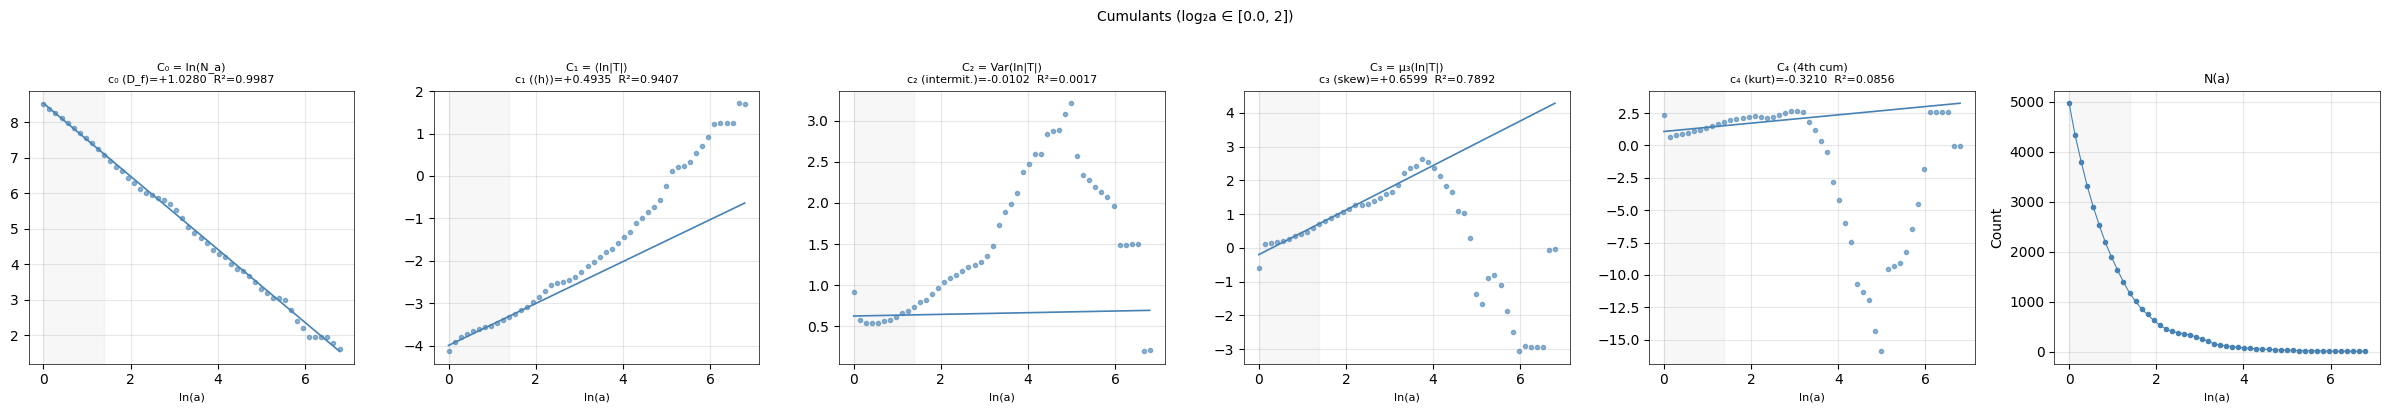

=== Cumulant coefficients ===
                c₀ (D_f) = +1.0280 ± 0.0124   R² = 0.998688
                c₁ (⟨h⟩) = +0.4935 ± 0.0413   R² = 0.940677
          c₂ (intermit.) = -0.0102 ± 0.0831   R² = 0.001670
               c₃ (skew) = +0.6599 ± 0.1137   R² = 0.789152
               c₄ (kurt) = -0.3210 ± 0.3498   R² = 0.085583


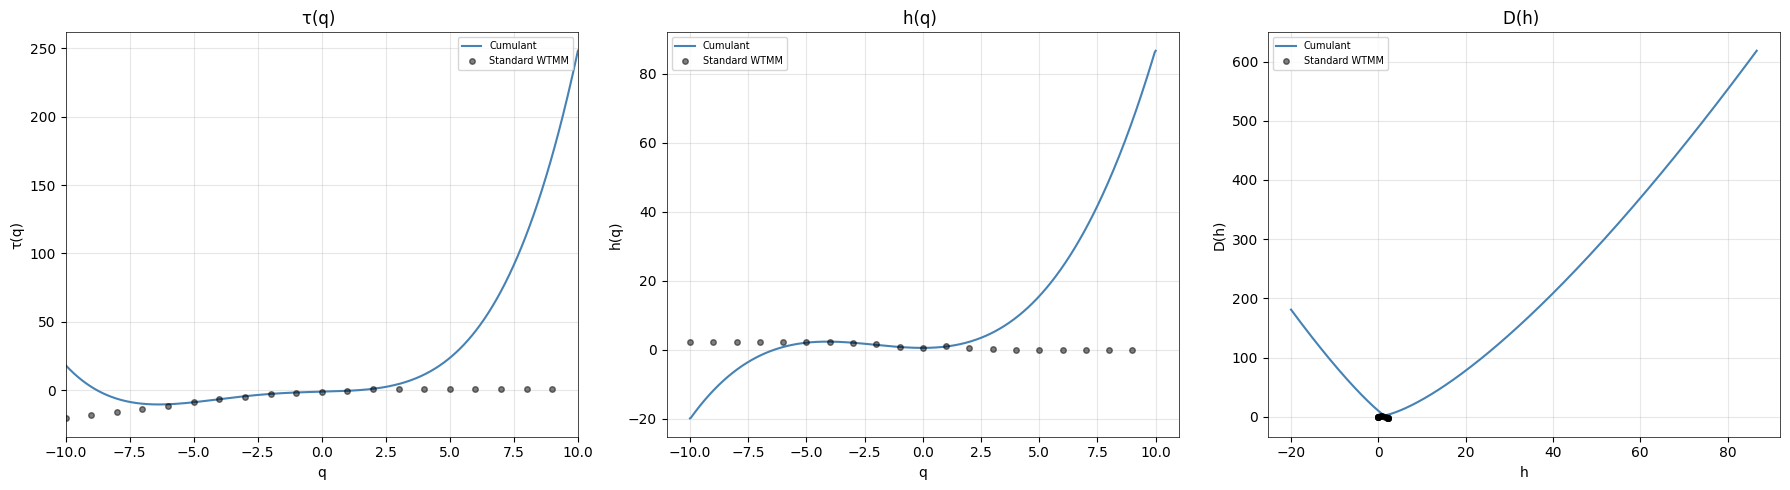


c₃ = +0.6599 → departure from log-normality


In [104]:
# Cumulant analysis — non-truncated only
# τ(q) = -c₀ + c₁q - c₂q²/2! + c₃q³/3! + ...
# cₙ = slope of Cₙ(a) vs ln(a)

Q_RANGE_CUMULANT = (-10, 10)  # valid q range for reconstruction

n_scales = len(extrep_ord)
n_voice_cum = pf['n_voice']
ln_a = np.log(scales[:n_scales])

# --- Compute cumulants C_n(a) at each scale ---
cumulant_names = ['C₀ = ln(N_a)', 'C₁ = ⟨ln|T|⟩', 'C₂ = Var(ln|T|)',
                  'C₃ = μ₃(ln|T|)', 'C₄ (4th cum)']
names_short = ['c₀ (D_f)', 'c₁ (⟨h⟩)', 'c₂ (intermit.)', 'c₃ (skew)', 'c₄ (kurt)']
n_cumulants = len(cumulant_names)
sign_conv = [-1, 1, -1, 1, -1]

C = np.full((n_cumulants, n_scales), np.nan)
N_a = np.zeros(n_scales)

for s in range(n_scales):
    ords = extrep_ord[s]
    N_a[s] = len(ords)
    if len(ords) < 3:
        continue
    ln_T = np.log(np.abs(ords) + 1e-300)
    m1 = np.mean(ln_T)
    d = ln_T - m1
    C[0, s] = np.log(len(ords))
    C[1, s] = m1
    C[2, s] = np.mean(d**2)
    C[3, s] = np.mean(d**3)
    C[4, s] = np.mean(d**4) - 3 * np.mean(d**2)**2

# --- Fit slopes over regression range ---
log2_a0 = np.log2(scales[0])
dx_scale = 1.0 / n_voice_cum
idx_lo = max(int(round((LOG2_A_MIN - log2_a0) / dx_scale)), 0)
idx_hi = min(int(round((LOG2_A_MAX - log2_a0) / dx_scale)), n_scales - 1)
fit_idx = np.arange(idx_lo, idx_hi + 1)
x_fit = ln_a[fit_idx]

c_coeffs = np.zeros(n_cumulants)
c_err = np.zeros(n_cumulants)
c_r2 = np.zeros(n_cumulants)

fig, axes = plt.subplots(1, n_cumulants + 1, figsize=(4 * (n_cumulants + 1), 4))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for n in range(n_cumulants):
    ax = axes[n]
    valid = np.isfinite(C[n])
    ax.plot(ln_a[valid], C[n, valid], 'o', color='steelblue', markersize=3, alpha=0.6)
    ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)

    y_fit = C[n, fit_idx]
    fmask = np.isfinite(y_fit)
    if fmask.sum() >= 3:
        slope, intercept = np.polyfit(x_fit[fmask], y_fit[fmask], 1)
        c_coeffs[n] = sign_conv[n] * slope
        y_pred = slope * x_fit[fmask] + intercept
        ss_res = np.sum((y_fit[fmask] - y_pred)**2)
        ss_tot = np.sum((y_fit[fmask] - y_fit[fmask].mean())**2)
        c_r2[n] = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
        n_pts = fmask.sum()
        c_err[n] = np.sqrt(ss_res / max(n_pts - 2, 1) /
                           np.sum((x_fit[fmask] - x_fit[fmask].mean())**2)) if n_pts > 2 else 0
        x_line = np.array([ln_a[valid].min(), ln_a[valid].max()])
        ax.plot(x_line, slope * x_line + intercept, '-', color='steelblue', lw=1.2)

    ax.set_title(f'{cumulant_names[n]}\n{names_short[n]}={c_coeffs[n]:+.4f}  R²={c_r2[n]:.4f}', fontsize=8)
    ax.set_xlabel('ln(a)', fontsize=8)
    ax.grid(True, alpha=0.3)

# N(a) panel
ax = axes[n_cumulants]
ax.plot(ln_a, N_a, 'o-', color='steelblue', markersize=3, lw=0.8)
ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)
ax.set_title('N(a)', fontsize=9)
ax.set_xlabel('ln(a)', fontsize=8)
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Cumulants (log₂a ∈ [{LOG2_A_MIN}, {LOG2_A_MAX}])', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# --- Print coefficients ---
print(f'=== Cumulant coefficients ===')
for n in range(n_cumulants):
    print(f'  {names_short[n]:>22s} = {c_coeffs[n]:+.4f} ± {c_err[n]:.4f}   R² = {c_r2[n]:.6f}')

# --- Reconstruct τ(q), h(q), D(h) ---
q_recon = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

tau_cum = -c_coeffs[0] + c_coeffs[1]*q_recon - c_coeffs[2]*q_recon**2/2 + c_coeffs[3]*q_recon**3/6 - c_coeffs[4]*q_recon**4/24
h_cum = np.gradient(tau_cum, q_recon)
D_cum = q_recon * h_cum - tau_cum

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# τ(q)
ax = axes[0]
ax.plot(q_recon, tau_cum, '-', color='steelblue', lw=1.5, label='Cumulant')

ax.plot(spectra['q_list'], spectra['tau_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('τ(q)')
ax.set_title(f'τ(q) ')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])

# h(q)
ax = axes[1]
ax.plot(q_recon, h_cum, '-', color='steelblue', lw=1.5, label='Cumulant')

ax.plot(spectra['q_list'], spectra['h_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('h(q)')
ax.set_title(f'h(q) ')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
m = D_cum > -0.5
ax.plot(h_cum[m], D_cum[m], '-', color='steelblue', lw=1.5, label='Cumulant')

ax.plot(spectra['h_q'], spectra['D_q'], 'ko', markersize=4, alpha=0.5, linestyle='none', label='Standard WTMM')
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title(f'D(h) ')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-normality check: if c₃ ≈ 0, the cascade is approximately log-normal
if abs(c_coeffs[3]) < 0.01:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} ≈ 0 → approximately log-normal cascade')
else:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} → departure from log-normality')


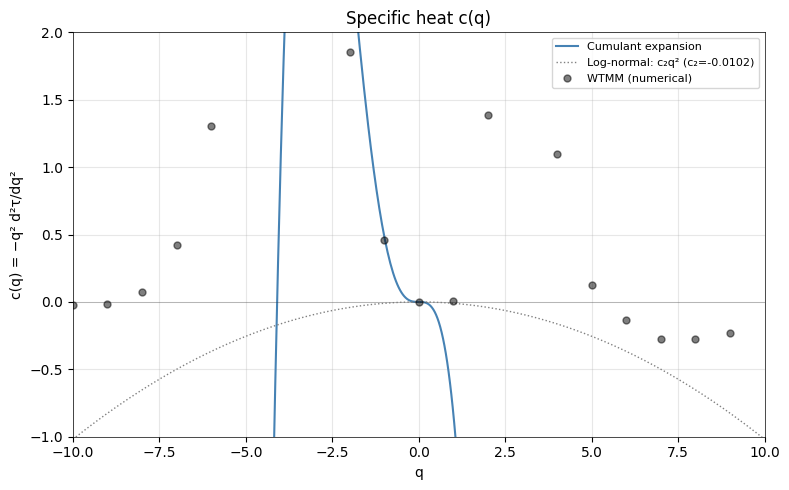

c₂ = -0.0102 (intermittency coefficient)
c₃ = 0.6599 (asymmetry; =0 for log-normal)
At q=1: c(1) = -0.8129


In [105]:
# Specific heat c(q) = -q² d²τ/dq² (Klamut et al. 2020 Eq. 14, Beck & Schlögl 1993 Eq. 3)
# Thermodynamic analogy: q → 1/kT, c(q) = dα/d(1/q) = -q² dh/dq = -q² d²τ/dq²
# c(q) > 0: thermally stable | c(q) < 0: thermally unstable | c(q) = 0: phase transition
# Log-normal model: c(q) = c₂ q² (from τ = -c₀ + c₁q - c₂q²/2, so d²τ/dq² = -c₂)

q_recon_ch = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

# Analytical from cumulant coefficients: c(q) = -q² d²τ/dq²
# d²τ/dq² ≈ -c₂ + c₃q - c₄q²/2  (from cumulant expansion)
d2tau_cum = -c_coeffs[2] + c_coeffs[3] * q_recon_ch - c_coeffs[4] * q_recon_ch**2 / 2
C_heat_cum = -q_recon_ch**2 * d2tau_cum

# Numerical from standard WTMM τ(q)
q_wtmm = spectra['q_list']
tau_wtmm = spectra['tau_q']
finite = np.isfinite(tau_wtmm)
if finite.sum() >= 3:
    d2tau_wtmm = np.gradient(np.gradient(tau_wtmm[finite], q_wtmm[finite]), q_wtmm[finite])
    C_heat_wtmm = -q_wtmm[finite]**2 * d2tau_wtmm
else:
    C_heat_wtmm = None

fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax.plot(q_recon_ch, C_heat_cum, '-', color='steelblue', lw=1.5, label='Cumulant expansion')
ax.axhline(0, color='k', ls='-', lw=0.5, alpha=0.3)

# Log-normal reference: c(q) = c₂ q² (since d²τ/dq² = -c₂ for log-normal)
C_lognormal = c_coeffs[2] * q_recon_ch**2
ax.plot(q_recon_ch, C_lognormal, ':', color='gray', lw=1,
        label=f'Log-normal: c₂q² (c₂={c_coeffs[2]:.4f})')

if C_heat_wtmm is not None:
    ax.plot(q_wtmm[finite], C_heat_wtmm, 'ko', markersize=5, alpha=0.5,
            label='WTMM (numerical)')

ax.set_xlabel('q')
ax.set_ylabel('c(q) = −q² d²τ/dq²')
ax.set_title('Specific heat c(q)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])
ax.set_ylim(-1, 2)
plt.tight_layout()
plt.show()

print(f'c₂ = {c_coeffs[2]:.4f} (intermittency coefficient)')
print(f'c₃ = {c_coeffs[3]:.4f} (asymmetry; =0 for log-normal)')
print(f'At q=1: c(1) = {-1.0 * d2tau_cum[np.argmin(np.abs(q_recon_ch - 1.0))]:.4f}')

In [106]:
# Universal Multifractal parameters (C₁, α) from WTMM
# K(q) = (q-1)·d - τ(q),  fit K(q) = C₁/(α-1)·(q^α - q) for α∈(0,2]
# c(γ) = Legendre transform of K(q) = codimension function = d - D(h)

from scipy.optimize import curve_fit

d = 1  # embedding dimension

# --- Compute K(q) from cumulant τ(q) ---
q_K = np.linspace(0.01, Q_RANGE_CUMULANT[1], 300)  # q > 0 for K(q)
tau_cum_K = -c_coeffs[0] + c_coeffs[1]*q_K - c_coeffs[2]*q_K**2/2 + c_coeffs[3]*q_K**3/6 - c_coeffs[4]*q_K**4/24
K_q = (q_K - 1) * d - tau_cum_K

# Also from standard WTMM
q_wtmm = np.array(spectra['q_list'], dtype=float)
tau_wtmm = np.array(spectra['tau_q'], dtype=float)
fmask = np.isfinite(tau_wtmm) & (q_wtmm > 0)
K_wtmm = (q_wtmm[fmask] - 1) * d - tau_wtmm[fmask]

# Theory K(q)
if has_theory:
    q_th_pos = theory_q[theory_q > 0]
    tau_th_pos = np.interp(q_th_pos, theory_q, theory_tau)
    K_theory = (q_th_pos - 1) * d - tau_th_pos

# --- Fit universal multifractal model ---
def K_universal(q, C1, alpha):
    """K(q) = C1/(alpha-1) * (q^alpha - q) for alpha != 1"""
    if abs(alpha - 1.0) < 1e-6:
        return C1 * q * np.log(q)
    return C1 / (alpha - 1) * (q**alpha - q)

# Fit on cumulant K(q) for q > 0.1
fit_mask = q_K > -1.1
try:
    popt, pcov = curve_fit(K_universal, q_K[fit_mask], K_q[fit_mask],
                           p0=[0.1, 1.5], bounds=([1e-6, 0.01], [5.0, 2.0]))
    C1_fit, alpha_fit = popt
    C1_err, alpha_err = np.sqrt(np.diag(pcov))
    K_fit = K_universal(q_K, C1_fit, alpha_fit)
    fit_ok = True
except Exception as e:
    print(f'Fit failed: {e}')
    fit_ok = False

# --- Legendre transform of K(q) → c(γ) ---
# γ = dK/dq,  c(γ) = q·γ - K(q)
dKdq = np.gradient(K_q, q_K)
gamma = dKdq
c_gamma = q_K * gamma - K_q

# Theory c(γ)
if has_theory:
    dK_th = np.gradient(K_theory, q_th_pos)
    gamma_th = dK_th
    c_gamma_th = q_th_pos * gamma_th - K_theory

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Panel 1: K(q) vs q
ax = axes[0]
ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5, label='Cumulant K(q)')
if fit_ok:
    ax.plot(q_K, K_fit, '--', color='orangered', lw=1.2,
            label=f'UM fit: C₁={C1_fit:.4f}, α={alpha_fit:.2f}')
ax.plot(q_wtmm[fmask], K_wtmm, 'ko', markersize=4, alpha=0.5, label='Standard WTMM')

ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('K(q)')
ax.set_title('K(q) = (q−1)d − τ(q)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 2: K(q)/C₁ vs q (normalized, like Lovejoy Fig 13)
ax = axes[1]
if fit_ok and C1_fit > 1e-8:
    ax.plot(q_K, K_q / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    # Reference curves for α = 0, 1, 2
    for a_ref, ls, lbl in [(0.0, ':', 'β-model (α=0)'),
                            (1.0, '-.', 'α=1'),
                            (2.0, '--', 'log-normal (α=2)')]:
        K_ref = K_universal(q_K, C1_fit, a_ref) / C1_fit
        ax.plot(q_K, K_ref, ls, color='gray', lw=0.8, label=lbl)
    ax.set_ylabel('K(q) / C₁')
else:
    ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5)
    ax.set_ylabel('K(q)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q')
ax.set_title('K(q)/C₁ — universal multifractal comparison')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 3: c(γ)/C₁ vs γ/C₁ (codimension, like Lovejoy Fig 14)
ax = axes[2]
if fit_ok and C1_fit > 1e-8:
    ax.plot(gamma / C1_fit, c_gamma / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
   
ax.set_title('c(γ)/C₁ — codimension function')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Universal Multifractal Analysis', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
if fit_ok:
    print(f'=== Universal Multifractal Parameters ===')
    print(f'  C₁ = {C1_fit:.4f} ± {C1_err:.4f}  (intermittency, cf. c₂ = {c_coeffs[2]:.4f})')
    print(f'  α  = {alpha_fit:.3f} ± {alpha_err:.3f}  (Lévy index, 0=β-model, 2=log-normal)')
    if alpha_fit > 1.8:
        print(f'  → Near log-normal (α ≈ 2)')
    elif alpha_fit < 0.2:
        print(f'  → Near β-model (α ≈ 0)')
    else:
        print(f'  → Lévy multifractal with α = {alpha_fit:.2f}')


NameError: name 'has_theory' is not defined

Re-running CWT to get 2D coefficient matrix...


NameError: name 'analysis_label' is not defined

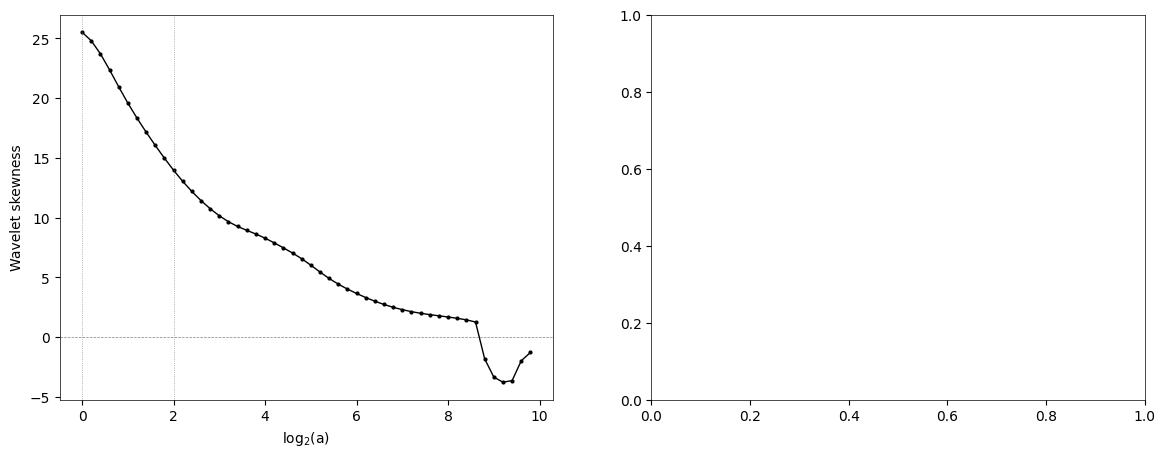

In [107]:
# Wavelet skewness and flatness (Dupont et al. 2020, Fig. 11)
# Skewness(a) = <T^3>/<T^2>^{3/2}  — asymmetry (ramp-cliffs -> nonzero)
# Flatness(a) = <T^4>/<T^2>^2      — intermittency (Gaussian=3)

from wtmm.stats import wavelet_skewness_flatness

# Recompute CWT if coeffs was overwritten (needs to be 2D: n_scales x n_samples)
if not hasattr(coeffs, 'shape') or coeffs.ndim != 2:
    print('Re-running CWT to get 2D coefficient matrix...')
    from wtmm.cwt import cwtd_fftw
    cwt_matrix, _, _ = cwtd_fftw(analysis_signal, a_min=A_MIN, n_oct=N_OCT,
                                  n_voice=N_VOICE, wavelet_name=wavelet_name, expo=EXPO)
else:
    cwt_matrix = coeffs
sf = wavelet_skewness_flatness(cwt_matrix, causal_ranges=valid_ranges)

log2_a = np.log2(scales)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax in (ax1, ax2):
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Skewness
fin = np.isfinite(sf['skewness'])
ax1.plot(log2_a[fin], sf['skewness'][fin], 'k.-', markersize=4, linewidth=1)
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.axvline(LOG2_A_MIN, color='gray', ls=':', lw=0.5)
ax1.axvline(LOG2_A_MAX, color='gray', ls=':', lw=0.5)
ax1.set_xlabel('log$_2$(a)')
ax1.set_ylabel('Wavelet skewness')
ax1.set_title(f'{analysis_label} — Wavelet skewness')
ax1.grid(True, alpha=0.2)

# Flatness
fin = np.isfinite(sf['flatness'])
ax2.plot(log2_a[fin], sf['flatness'][fin], 'k.-', markersize=4, linewidth=1)
ax2.axhline(3, color='red', ls='--', lw=0.8, label='Gaussian (F=3)')
ax2.axvline(LOG2_A_MIN, color='gray', ls=':', lw=0.5)
ax2.axvline(LOG2_A_MAX, color='gray', ls=':', lw=0.5)
ax2.set_xlabel('log$_2$(a)')
ax2.set_ylabel('Wavelet flatness')
ax2.set_title(f'{analysis_label} — Wavelet flatness')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Report values at scaling range boundaries
for label, la in [('a_min', LOG2_A_MIN), ('a_max', LOG2_A_MAX)]:
    idx = np.argmin(np.abs(log2_a - la))
    print(f'  At log2(a)={la:.1f}: skewness={sf["skewness"][idx]:.4f}, flatness={sf["flatness"][idx]:.4f}')

Reference scale: index 36, a=147.03, log2(a)=7.20 (~24.5 hours)


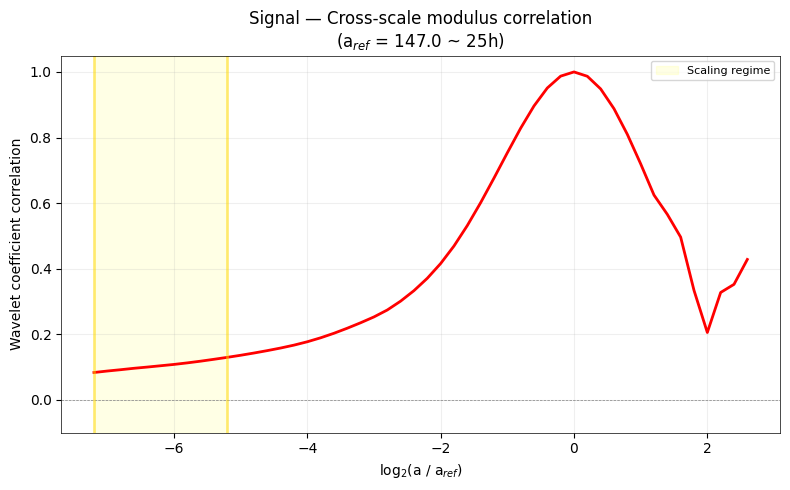

In [108]:
# Cross-scale modulus correlation (Dupont et al. 2020, Fig. 12)
# corr(a) = Pearson( |T(t, a_ref)|, |T(t, a)| )
# x-axis: log2(a/a_ref) so reference scale is at 0, correlation=1
# Shows whether fine-scale fluctuations are driven by large-scale structures.

from wtmm.stats import magnitude_correlation_cross_scale

# Reference scale: daily tidal fluctuation
SAMPLE_RATE_MIN = 10
SAMPLES_PER_DAY = int(24 * 60 / SAMPLE_RATE_MIN)
REF_SCALE = SAMPLES_PER_DAY  # ~1 day for 10-min data
FINE_SCALE_IDX = np.argmin(np.abs(scales - REF_SCALE))
print(f'Reference scale: index {FINE_SCALE_IDX}, a={scales[FINE_SCALE_IDX]:.2f}, '
      f'log2(a)={np.log2(scales[FINE_SCALE_IDX]):.2f} '
      f'(~{scales[FINE_SCALE_IDX] * SAMPLE_RATE_MIN / 60:.1f} hours)')

if not hasattr(coeffs, 'shape') or coeffs.ndim != 2:
    from wtmm.cwt import cwtd_fftw
    cwt_matrix, _, _ = cwtd_fftw(analysis_signal, a_min=A_MIN, n_oct=N_OCT,
                                  n_voice=N_VOICE, wavelet_name=wavelet_name, expo=EXPO)
else:
    cwt_matrix = coeffs
corr = magnitude_correlation_cross_scale(cwt_matrix, FINE_SCALE_IDX,
                                          causal_ranges=valid_ranges)

# x-axis: log2(a / a_ref) — relative to reference scale
log2_a = np.log2(scales)
log2_a_ref = np.log2(scales[FINE_SCALE_IDX])
x_rel = log2_a - log2_a_ref  # 0 at reference scale

fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

fin = np.isfinite(corr)
ax.plot(x_rel[fin], corr[fin], 'r-', linewidth=2)
ax.axhline(0, color='gray', ls='--', lw=0.5)

# Scaling regime relative to reference
ax.axvline(LOG2_A_MIN - log2_a_ref, color='gold', ls='-', lw=2, alpha=0.5)
ax.axvline(LOG2_A_MAX - log2_a_ref, color='gold', ls='-', lw=2, alpha=0.5)
ax.axvspan(LOG2_A_MIN - log2_a_ref, LOG2_A_MAX - log2_a_ref,
           color='yellow', alpha=0.1, label='Scaling regime')

ax.set_xlabel('log$_2$(a / a$_{ref}$)')
ax.set_ylabel('Wavelet coefficient correlation')
_label = analysis_label if 'analysis_label' in dir() else 'Signal'
ax.set_title(f'{_label} — Cross-scale modulus correlation\n'
             f'(a$_{{ref}}$ = {scales[FINE_SCALE_IDX]:.1f} '
             f'~ {scales[FINE_SCALE_IDX]*SAMPLE_RATE_MIN/60:.0f}h)')
ax.set_ylim(-0.1, 1.05)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

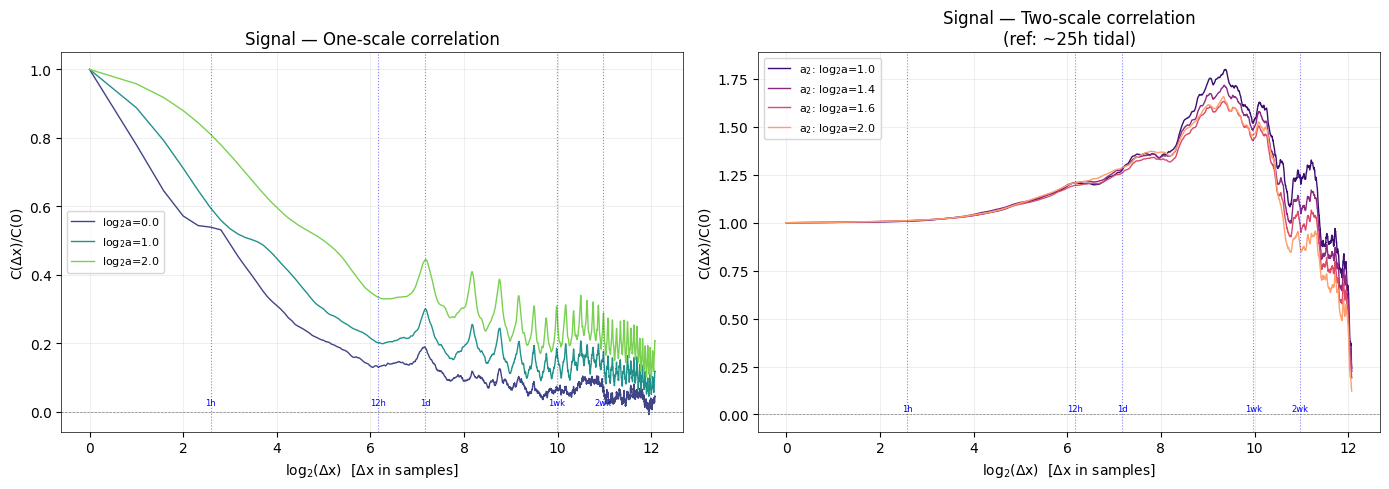

In [109]:
# Space-scale magnitude correlation (Arneodo et al. 1998)
# C(dx, a1, a2) = <w~(x,a1) * w~(x+dx,a2)>  where w = ln|T| centered
# One-scale: a1=a2 (autocorrelation of log-modulus at a given scale)
# Two-scale: a1!=a2 (cross-correlation between different scales)
# x-axis: log2(dx) where dx is in samples

from wtmm.stats import space_scale_correlation
_label = analysis_label if 'analysis_label' in dir() else 'Signal'

log2_a = np.log2(scales)
if not hasattr(coeffs, 'shape') or coeffs.ndim != 2:
    from wtmm.cwt import cwtd_fftw
    cwt_matrix, _, _ = cwtd_fftw(analysis_signal, a_min=A_MIN, n_oct=N_OCT,
                                  n_voice=N_VOICE, wavelet_name=wavelet_name, expo=EXPO)
else:
    cwt_matrix = coeffs

# Physical timescale markers (in samples)
SAMPLE_RATE_MIN = 10
SAMPLES_PER_DAY = int(24 * 60 / SAMPLE_RATE_MIN)
LAG_MARKERS = {
    '1h': 6,
    '12h': SAMPLES_PER_DAY // 2,
    '1d': SAMPLES_PER_DAY,
    '1wk': SAMPLES_PER_DAY * 7,
    '2wk': SAMPLES_PER_DAY * 14,
}

# Max lag: limit to ~1 month to avoid noisy tail from few-sample averages
MAX_LAG_SAMPLES = SAMPLES_PER_DAY * 30

# Pick representative scales
scale_targets = [LOG2_A_MIN, (LOG2_A_MIN + LOG2_A_MAX)/2, LOG2_A_MAX]
scale_indices = [np.argmin(np.abs(log2_a - t)) for t in scale_targets]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax in (ax1, ax2):
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# --- Left: One-scale correlation at several scales ---
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(scale_indices)))
for ci, si in enumerate(scale_indices):
    result = space_scale_correlation(cwt_matrix, si, max_lag=MAX_LAG_SAMPLES,
                                         causal_ranges=valid_ranges)
    fin = np.isfinite(result['C_norm'])
    log2_lag = np.log2(result['lags'] + 1)
    ax1.plot(log2_lag[fin], result['C_norm'][fin], '-', color=colors[ci],
             linewidth=1, label=f'log$_2$a={log2_a[si]:.1f}')

ax1.axhline(0, color='gray', ls='--', lw=0.5)
for label, n_samp in LAG_MARKERS.items():
    lv = np.log2(n_samp)
    ax1.axvline(lv, color='blue', ls=':', lw=0.8, alpha=0.5)
    ax1.annotate(label, (lv, 0.02), fontsize=6, color='blue', ha='center')
ax1.set_xlabel('log$_2$(\u0394x)  [\u0394x in samples]')
ax1.set_ylabel('C(\u0394x)/C(0)')
ax1.set_title(f'{_label} — One-scale correlation')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)

# --- Right: Two-scale correlation (tidal ref vs coarser) ---
# Use daily tidal as reference
tidal_idx = np.argmin(np.abs(scales - SAMPLES_PER_DAY))
coarse_targets = np.linspace(LOG2_A_MIN + 1, LOG2_A_MAX, 4)
coarse_indices = [np.argmin(np.abs(log2_a - t)) for t in coarse_targets]
colors2 = plt.cm.magma(np.linspace(0.2, 0.8, len(coarse_indices)))
for ci, si in enumerate(coarse_indices):
    result = space_scale_correlation(cwt_matrix, tidal_idx, si,
                                     max_lag=MAX_LAG_SAMPLES, causal_ranges=valid_ranges)
    fin = np.isfinite(result['C_norm'])
    log2_lag = np.log2(result['lags'] + 1)
    ax2.plot(log2_lag[fin], result['C_norm'][fin], '-', color=colors2[ci],
             linewidth=1, label=f'a$_2$: log$_2$a={log2_a[si]:.1f}')

ax2.axhline(0, color='gray', ls='--', lw=0.5)
for label, n_samp in LAG_MARKERS.items():
    lv = np.log2(n_samp)
    ax2.axvline(lv, color='blue', ls=':', lw=0.8, alpha=0.5)
    ax2.annotate(label, (lv, 0.02), fontsize=6, color='blue', ha='center')
ax2.set_xlabel('log$_2$(\u0394x)  [\u0394x in samples]')
ax2.set_ylabel('C(\u0394x)/C(0)')
ax2.set_title(f'{_label} — Two-scale correlation\n'
              f'(ref: ~{scales[tidal_idx]*SAMPLE_RATE_MIN/60:.0f}h tidal)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

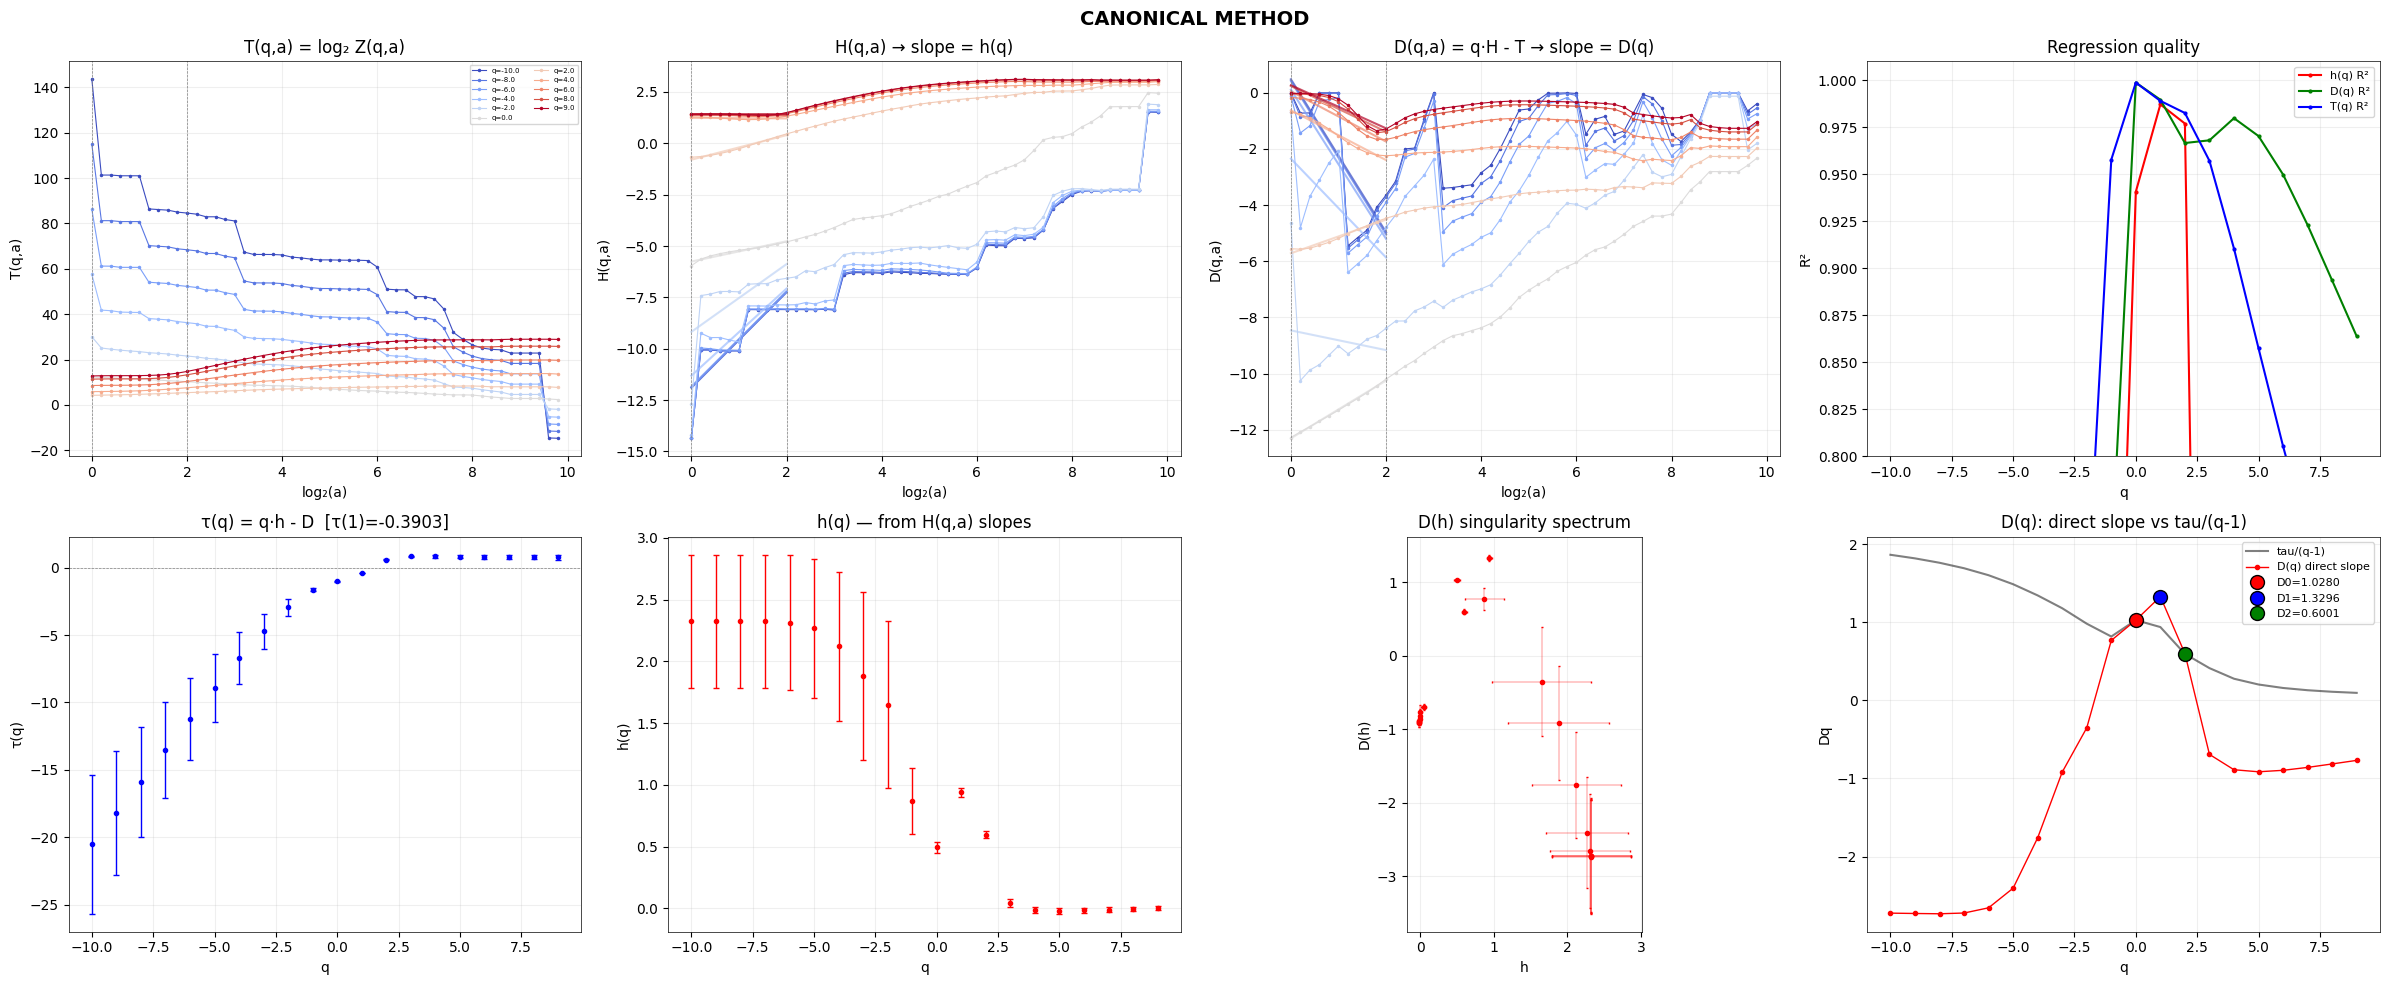

=== CANONICAL ===
Keys in spec_can: ['D_R2', 'D_err', 'D_q', 'L_ref', 'h_R2', 'h_err', 'h_q', 'method', 'q_list', 'tau_1', 'tau_R2', 'tau_err', 'tau_q']
τ(1) = -0.3903
h range: [-0.0200, 2.3249]
D(h) peak: 1.3296
D(q) direct:  D₀=1.0280  D₁=1.3296  D₂=0.6001
τ/(q-1):      D₀=1.0280  D₁=0.9392  D₂=0.5955


In [110]:
# ===== CANONICAL METHOD =====
# h(q) = slope of H(q,a) vs log₂a  (direct fit)
# D(q) = slope of D(q,a) vs log₂a  (direct fit)
# τ(q) = q·h(q) - D(q)             (derived)
# No normalization, no shifts.

from wtmm.spectra import compute_spectra
from wtmm.partition import pf_get_T, pf_get_H, pf_get_D

spec_can = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX,
                           method='canonical')

q_c = spec_can['q_list']
tau_c = spec_can['tau_q']
h_c = spec_can['h_q']
D_c = spec_can['D_q']
n_q_c = len(q_c)

# --- Regression range indices ---
log2_a_full = pf['log2_a']
dx = 1.0 / pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
idx_min = max(int((LOG2_A_MIN - log2_a0) / dx), 0)
idx_max = min(int((LOG2_A_MAX - log2_a0) / dx), pf['index_max'])
fit_idx = np.arange(idx_min, idx_max + 1)
x_fit = log2_a0 + dx * fit_idx
valid = slice(0, pf['index_max'] + 1)
x_full = log2_a_full[valid]

# Subsample q for plot legibility
Q_STEP = max(1, n_q_c // 10)
q_plot_idx = list(range(0, n_q_c, Q_STEP))
if q_plot_idx[-1] != n_q_c - 1:
    q_plot_idx.append(n_q_c - 1)
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_plot_idx)))

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for ax_ in axes.flat:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
fig.suptitle('CANONICAL METHOD', fontsize=14, fontweight='bold')

# ---- Row 1: Partition functions vs log₂(a) ----

# T(q,a) = log₂ Z(q,a)
ax = axes[0, 0]
for ci, qi in enumerate(q_plot_idx):
    y = pf_get_T(pf, qi)[valid]
    ax.plot(x_full, y, 'o-', color=colors_q[ci], markersize=1.5, linewidth=0.8,
            label=f'q={q_c[qi]:.1f}')
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('T(q,a)')
ax.set_title('T(q,a) = log₂ Z(q,a)')
ax.legend(fontsize=5, ncol=2)
ax.grid(True, alpha=0.2)

# H(q,a) — fitted for h(q)
ax = axes[0, 1]
for ci, qi in enumerate(q_plot_idx):
    y = pf_get_H(pf, qi)[valid]
    ax.plot(x_full, y, 'o-', color=colors_q[ci], markersize=1.5, linewidth=0.8)
    if np.isfinite(h_c[qi]):
        y_line = h_c[qi] * x_fit + np.mean(pf_get_H(pf, qi)[fit_idx] - h_c[qi] * x_fit)
        ax.plot(x_fit, y_line, '-', color=colors_q[ci], linewidth=1.5, alpha=0.7)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) → slope = h(q)')
ax.grid(True, alpha=0.2)

# D(q,a) — fitted for D(q)
ax = axes[0, 2]
for ci, qi in enumerate(q_plot_idx):
    y = pf_get_D(pf, qi, q_c[qi])[valid]
    ax.plot(x_full, y, 'o-', color=colors_q[ci], markersize=1.5, linewidth=0.8)
    if np.isfinite(D_c[qi]):
        y_line = D_c[qi] * x_fit + np.mean(pf_get_D(pf, qi, q_c[qi])[fit_idx] - D_c[qi] * x_fit)
        ax.plot(x_fit, y_line, '-', color=colors_q[ci], linewidth=1.5, alpha=0.7)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q·H - T → slope = D(q)')
ax.grid(True, alpha=0.2)

# R² quality (handle missing keys gracefully)
ax = axes[0, 3]
for key, label, color in [('h_R2', 'h(q) R²', 'r'), ('D_R2', 'D(q) R²', 'g'), ('tau_R2', 'T(q) R²', 'b')]:
    if key in spec_can:
        vals = spec_can[key]
        fin = np.isfinite(vals)
        ax.plot(q_c[fin], vals[fin], f'{color}.-', markersize=4, label=label)
ax.set_xlabel('q')
ax.set_ylabel('R²')
ax.set_title('Regression quality')
ax.set_ylim(0.8, 1.01)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ---- Row 2: Spectra ----

# τ(q)
ax = axes[1, 0]
fin = np.isfinite(tau_c)
tau_err = spec_can.get('tau_err')
if tau_err is not None and np.any(np.isfinite(tau_err)):
    ax.errorbar(q_c[fin], tau_c[fin], yerr=tau_err[fin],
                fmt='bo', markersize=3, capsize=2, linewidth=1)
else:
    ax.plot(q_c[fin], tau_c[fin], 'bo', markersize=3)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
q1i = np.argmin(np.abs(q_c - 1.0))
ax.set_title(f'τ(q) = q·h - D  [τ(1)={tau_c[q1i]:.4f}]')
ax.grid(True, alpha=0.2)

# h(q)
ax = axes[1, 1]
fin = np.isfinite(h_c)
h_err = spec_can.get('h_err')
if h_err is not None and np.any(np.isfinite(h_err)):
    ax.errorbar(q_c[fin], h_c[fin], yerr=h_err[fin],
                fmt='ro', markersize=3, capsize=2, linewidth=1)
else:
    ax.plot(q_c[fin], h_c[fin], 'ro', markersize=3)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) — from H(q,a) slopes')
ax.grid(True, alpha=0.2)

# D(h) singularity spectrum
ax = axes[1, 2]
fin = np.isfinite(h_c) & np.isfinite(D_c)
D_err = spec_can.get('D_err')
if h_err is not None and D_err is not None:
    ax.errorbar(h_c[fin], D_c[fin], xerr=h_err[fin],
                yerr=D_err[fin], fmt='ro', markersize=3,
                capsize=1, linewidth=0.3, linestyle='none')
else:
    ax.plot(h_c[fin], D_c[fin], 'ro', markersize=3, linestyle='none')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

# D_q generalized dimensions — TWO definitions
ax = axes[1, 3]
# Method 1: D_q = τ(q)/(q-1), where τ = q·h - D (derived)
D_q_tau = np.full_like(q_c, np.nan)
for i in range(len(q_c)):
    if np.isclose(q_c[i], 1.0):
        D_q_tau[i] = h_c[i]  # L'Hopital: lim tau/(q-1) = dtau/dq = h(1)
    elif np.isfinite(tau_c[i]):
        D_q_tau[i] = tau_c[i] / (q_c[i] - 1.0)
# Method 2: Direct from D(q,a) slope (canonical advantage)
fin_tau = np.isfinite(D_q_tau)
fin_D = np.isfinite(D_c)
ax.plot(q_c[fin_tau], D_q_tau[fin_tau], 'k-', linewidth=1.5, alpha=0.5, label='tau/(q-1)')
ax.plot(q_c[fin_D], D_c[fin_D], 'ro-', markersize=3, linewidth=1, label='D(q) direct slope')
for qv, nm, col in [(0, 'D0', 'red'), (1, 'D1', 'blue'), (2, 'D2', 'green')]:
    idx = np.argmin(np.abs(q_c - qv))
    if np.isfinite(D_c[idx]):
        ax.plot(q_c[idx], D_c[idx], 'o', color=col, markersize=10,
                markeredgecolor='k', zorder=5, label=f'{nm}={D_c[idx]:.4f}')
ax.set_xlabel('q')
ax.set_ylabel('Dq')
ax.set_title('D(q): direct slope vs tau/(q-1)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print('=== CANONICAL ===')
print(f'Keys in spec_can: {sorted(spec_can.keys())}')
print(f'τ(1) = {tau_c[q1i]:.4f}')
print(f'h range: [{np.nanmin(h_c):.4f}, {np.nanmax(h_c):.4f}]')
print(f'D(h) peak: {np.nanmax(D_c):.4f}')
print(f'D(q) direct:  D₀={D_c[np.argmin(np.abs(q_c))]:.4f}  '
      f'D₁={D_c[np.argmin(np.abs(q_c-1))]:.4f}  '
      f'D₂={D_c[np.argmin(np.abs(q_c-2))]:.4f}')
print(f'τ/(q-1):      D₀={D_q_tau[np.argmin(np.abs(q_c))]:.4f}  '
      f'D₁={D_q_tau[np.argmin(np.abs(q_c-1))]:.4f}  '
      f'D₂={D_q_tau[np.argmin(np.abs(q_c-2))]:.4f}')


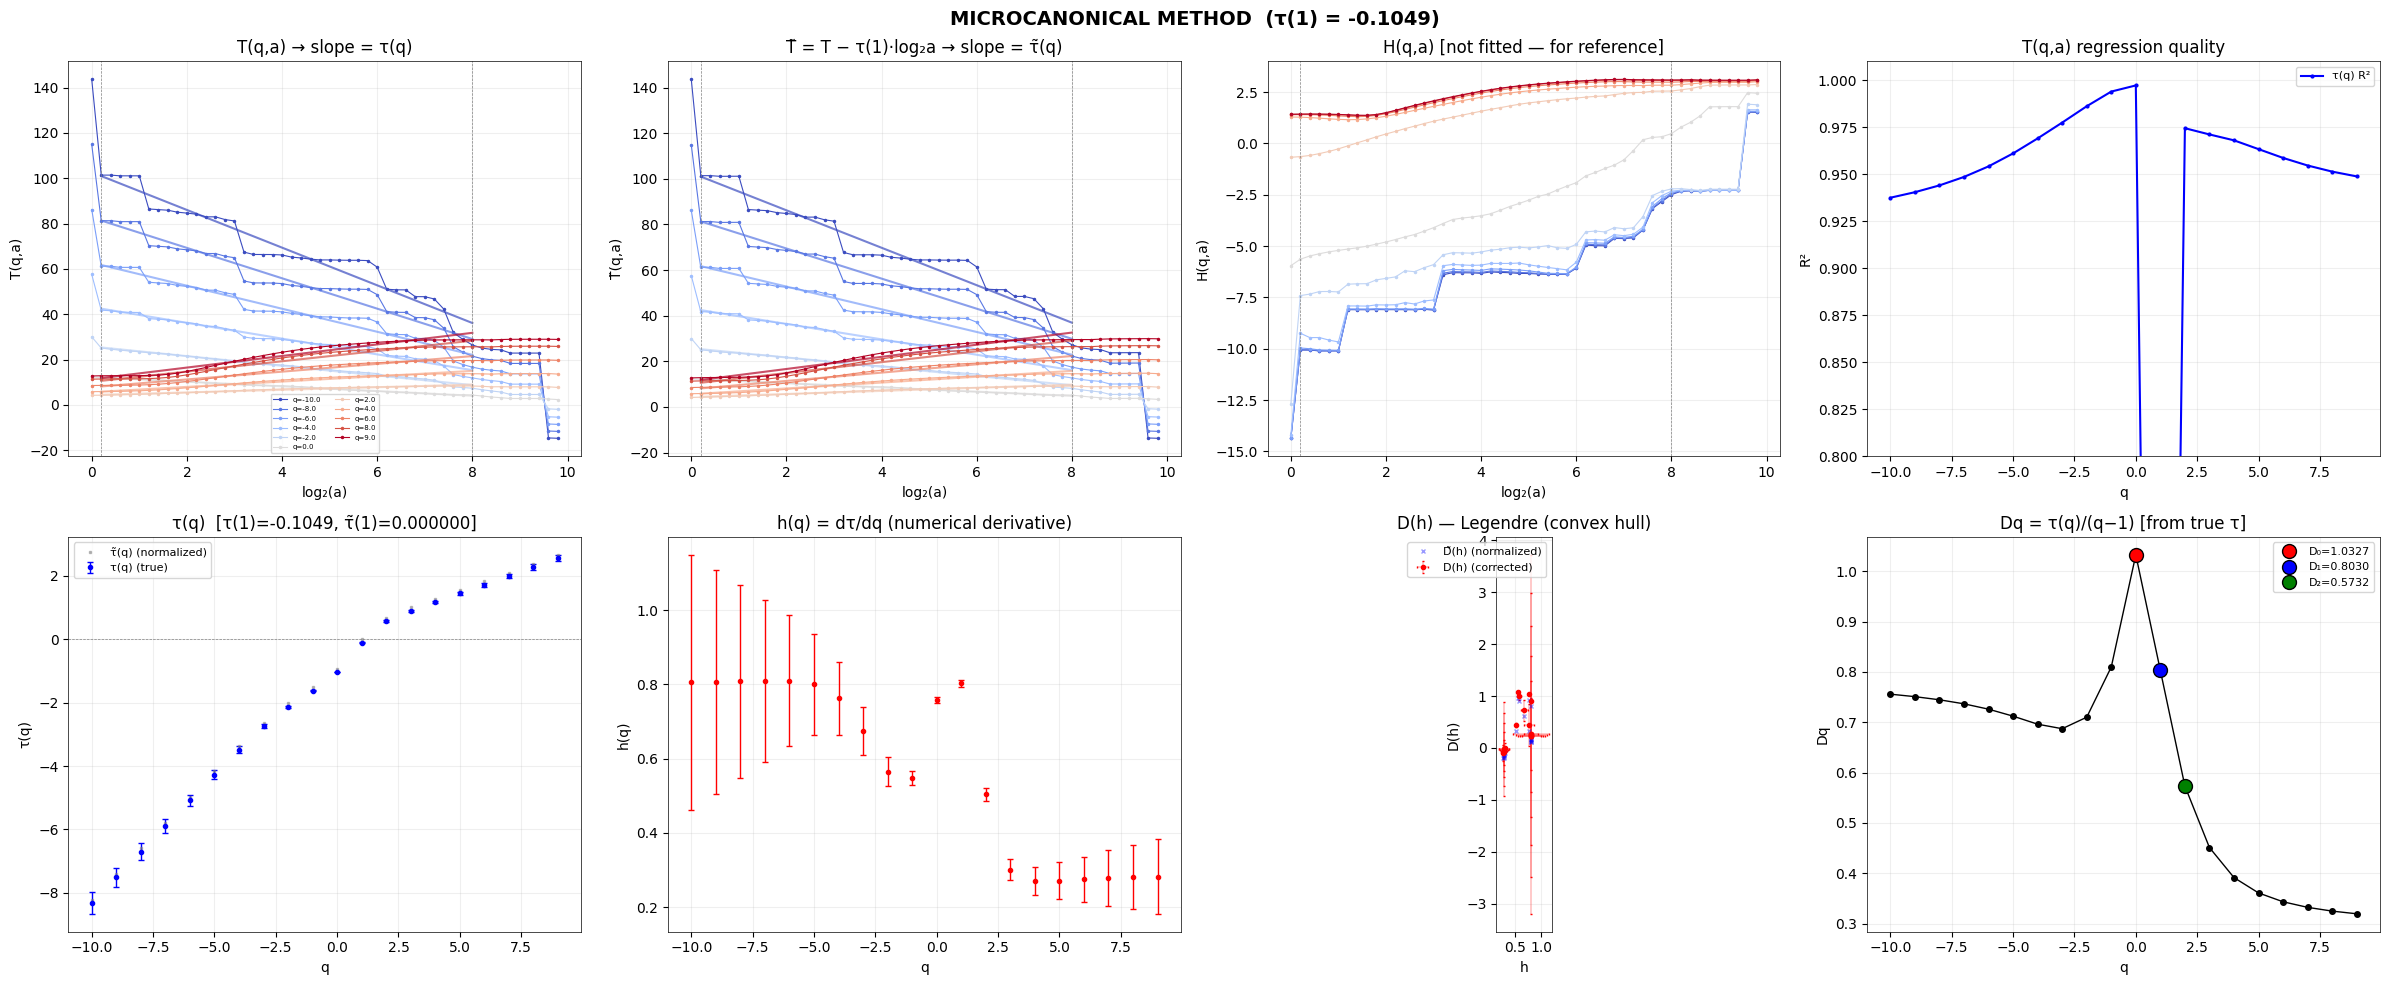

=== MICROCANONICAL ===
τ(1) = -0.1049
h range: [0.2706, 0.8101]
D(h) peak (true): 1.0710
D(h) peak (norm): 0.9661
D₀=1.0327  D₁=0.8030  D₂=0.5732


In [95]:
# ===== MICROCANONICAL METHOD =====
# τ(q) = slope of T(q,a) vs log₂a  (direct fit)
# h(q) = dτ/dq                      (numerical derivative)
# D(q) = q·h - τ                    (derived via Legendre)
# No normalization, no shifts.

from wtmm.spectra import compute_spectra
from wtmm.partition import pf_get_T, pf_get_H, pf_get_D

spec_mic = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX,
                           method='legendre')

q_m = spec_mic['q_list']
tau_m = spec_mic['tau_q']           # true τ (corrected back: τ̃ + τ(1))
tau_m_norm = spec_mic['tau_q_norm'] # normalized τ̃ (τ̃(1)=0)
h_m = spec_mic['h_q']
D_m = spec_mic['D_q']              # true D (corrected back: D̃ - τ(1))
D_m_norm = spec_mic['D_q_norm']    # normalized D̃
tau_1_mic = spec_mic['tau_1']
n_q_m = len(q_m)

# --- Regression range indices ---
log2_a_full = pf['log2_a']
dx = 1.0 / pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
idx_min = max(int((LOG2_A_MIN - log2_a0) / dx), 0)
idx_max = min(int((LOG2_A_MAX - log2_a0) / dx), pf['index_max'])
fit_idx = np.arange(idx_min, idx_max + 1)
x_fit = log2_a0 + dx * fit_idx
valid = slice(0, pf['index_max'] + 1)
x_full = log2_a_full[valid]

# Subsample q for plot legibility
Q_STEP = max(1, n_q_m // 10)
q_plot_idx = list(range(0, n_q_m, Q_STEP))
if q_plot_idx[-1] != n_q_m - 1:
    q_plot_idx.append(n_q_m - 1)
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_plot_idx)))

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for ax_ in axes.flat:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
fig.suptitle(f'MICROCANONICAL METHOD  (τ(1) = {tau_1_mic:.4f})', fontsize=14, fontweight='bold')

# ---- Row 1: Partition functions vs log₂(a) ----

# T(q,a) raw
ax = axes[0, 0]
for ci, qi in enumerate(q_plot_idx):
    y = pf_get_T(pf, qi)[valid]
    ax.plot(x_full, y, 'o-', color=colors_q[ci], markersize=1.5, linewidth=0.8,
            label=f'q={q_m[qi]:.1f}')
    # Regression line (true τ slope)
    if np.isfinite(tau_m[qi]):
        y_line = tau_m[qi] * x_fit + np.mean(pf_get_T(pf, qi)[fit_idx] - tau_m[qi] * x_fit)
        ax.plot(x_fit, y_line, '-', color=colors_q[ci], linewidth=1.5, alpha=0.7)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('T(q,a)')
ax.set_title('T(q,a) → slope = τ(q)')
ax.legend(fontsize=5, ncol=2)
ax.grid(True, alpha=0.2)

# T̃(q,a) = T - τ(1)·log₂a (normalized, for visual: slopes = τ̃)
ax = axes[0, 1]
for ci, qi in enumerate(q_plot_idx):
    y = pf_get_T(pf, qi)[valid] - tau_1_mic * x_full
    ax.plot(x_full, y, 'o-', color=colors_q[ci], markersize=1.5, linewidth=0.8)
    if np.isfinite(tau_m_norm[qi]):
        y_line = tau_m_norm[qi] * x_fit + np.mean(
            pf_get_T(pf, qi)[fit_idx] - tau_1_mic * x_fit - tau_m_norm[qi] * x_fit)
        ax.plot(x_fit, y_line, '-', color=colors_q[ci], linewidth=1.5, alpha=0.7)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('T̃(q,a)')
ax.set_title('T̃ = T − τ(1)·log₂a → slope = τ̃(q)')
ax.grid(True, alpha=0.2)

# H(q,a) and D(q,a) for reference (not fitted in microcanonical)
ax = axes[0, 2]
for ci, qi in enumerate(q_plot_idx):
    y = pf_get_H(pf, qi)[valid]
    ax.plot(x_full, y, 'o-', color=colors_q[ci], markersize=1.5, linewidth=0.8)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) [not fitted — for reference]')
ax.grid(True, alpha=0.2)

# R² of T(q,a) fits
ax = axes[0, 3]
fin = np.isfinite(spec_mic.get('tau_R2', np.full(n_q_m, np.nan)))
ax.plot(q_m[fin], spec_mic.get('tau_R2', np.full(n_q_m, np.nan))[fin], 'b.-', markersize=4, label='τ(q) R²')
ax.set_xlabel('q')
ax.set_ylabel('R²')
ax.set_title('T(q,a) regression quality')
ax.set_ylim(0.8, 1.01)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ---- Row 2: Spectra ----

# τ(q) — both normalized and true
ax = axes[1, 0]
fin = np.isfinite(tau_m)
ax.errorbar(q_m[fin], tau_m[fin], yerr=spec_mic['tau_err'][fin],
            fmt='bo', markersize=3, capsize=2, linewidth=1, label='τ(q) (true)')
ax.plot(q_m[fin], tau_m_norm[fin], 's', color='gray', markersize=2,
        alpha=0.5, label='τ̃(q) (normalized)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
q1i = np.argmin(np.abs(q_m - 1.0))
ax.set_title(f'τ(q)  [τ(1)={tau_m[q1i]:.4f}, τ̃(1)={tau_m_norm[q1i]:.6f}]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# h(q) = dτ/dq
ax = axes[1, 1]
fin = np.isfinite(h_m)
if spec_mic.get('h_err') is not None:
    ax.errorbar(q_m[fin], h_m[fin], yerr=spec_mic['h_err'][fin],
                fmt='ro', markersize=3, capsize=2, linewidth=1)
else:
    ax.plot(q_m[fin], h_m[fin], 'ro', markersize=3)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) = dτ/dq (numerical derivative)')
ax.grid(True, alpha=0.2)

# D(h) singularity spectrum (true, corrected)
ax = axes[1, 2]
fin = np.isfinite(h_m) & np.isfinite(D_m)
if spec_mic.get('h_err') is not None and spec_mic.get('D_err') is not None:
    ax.errorbar(h_m[fin], D_m[fin], xerr=spec_mic['h_err'][fin],
                yerr=spec_mic['D_err'][fin], fmt='ro', markersize=3,
                capsize=1, linewidth=0.3, linestyle='none', label='D(h) (corrected)')
else:
    ax.plot(h_m[fin], D_m[fin], 'ro', markersize=3, linestyle='none', label='D(h) (corrected)')
# Also show normalized D̃(h) for comparison
fin_n = np.isfinite(h_m) & np.isfinite(D_m_norm)
ax.plot(h_m[fin_n], D_m_norm[fin_n], 'bx', markersize=3, alpha=0.4,
        linestyle='none', label='D̃(h) (normalized)')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) — Legendre (convex hull)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# D_q generalized dimensions (from true τ)
ax = axes[1, 3]
D_q_mic = np.full_like(q_m, np.nan)
for i in range(len(q_m)):
    if np.isclose(q_m[i], 1.0):
        D_q_mic[i] = h_m[i]  # L'Hôpital
    elif np.isfinite(tau_m[i]):
        D_q_mic[i] = tau_m[i] / (q_m[i] - 1.0)
fin = np.isfinite(D_q_mic)
ax.plot(q_m[fin], D_q_mic[fin], 'ko-', markersize=4, linewidth=1)
for qv, nm, col in [(0, 'D₀', 'red'), (1, 'D₁', 'blue'), (2, 'D₂', 'green')]:
    idx = np.argmin(np.abs(q_m - qv))
    if np.isfinite(D_q_mic[idx]):
        ax.plot(q_m[idx], D_q_mic[idx], 'o', color=col, markersize=10,
                markeredgecolor='k', zorder=5, label=f'{nm}={D_q_mic[idx]:.4f}')
ax.set_xlabel('q')
ax.set_ylabel('Dq')
ax.set_title('Dq = τ(q)/(q−1) [from true τ]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print('=== MICROCANONICAL ===')
print(f'τ(1) = {tau_1_mic:.4f}')
print(f'h range: [{np.nanmin(h_m):.4f}, {np.nanmax(h_m):.4f}]')
print(f'D(h) peak (true): {np.nanmax(D_m):.4f}')
print(f'D(h) peak (norm): {np.nanmax(D_m_norm):.4f}')
print(f'D₀={D_q_mic[np.argmin(np.abs(q_m))]:.4f}  '
      f'D₁={D_q_mic[np.argmin(np.abs(q_m-1))]:.4f}  '
      f'D₂={D_q_mic[np.argmin(np.abs(q_m-2))]:.4f}')